In [ ]:
# Libraries to install
!pip install medmnist
!pip install torch torchvision
!pip install dill

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114250 sha256=38020f1813330ebfbcd453cb2e7d2f5087a1562863b0933a4323a284c0502625
  Stored in directory: /root/.cache/pip/wheels/19/39/2f/2d3cadc408a8804103f1c34ddd4b9f6a93497b11fa96fe738e
Successfully built fire
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 2.3 MB/s eta 0:00:00


In [ ]:
# Packages
from medmnist import OrganAMNIST
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns
import shutil
import itertools
import time

from tqdm import tqdm

In [ ]:
# To save and load models
# Make sure to have a top level folder called COMP551_A3 in Google Drive
import dill as pickle
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Set Up

In [ ]:
num_classes=11

In [ ]:
# Function to calculate mean and standard deviation
def mean_var_calc(dataset_name='OrganAMNIST', size=28):
    if dataset_name == 'OrganAMNIST':
        # Use ToTensor() for initial transformation
        transform = transforms.Compose([transforms.ToTensor()])
        train_data = OrganAMNIST(split="train", transform=transform, download=True, size=size)
    else:
        raise ValueError(f"Dataset {dataset_name} not supported")

    # Create a DataLoader with a batch size of 1000 for efficient calculation
    train_loader = DataLoader(train_data, batch_size=1000, shuffle=False)

    # Initialize accumulators for mean and standard deviation calculation
    sum, squared_sum, N = 0.0, 0.0, 0

    # Accumulate sums to calculate mean and std
    for data, _ in train_loader:
        sum += data.sum(dim=[0, 2, 3])
        squared_sum += (data ** 2).sum(dim=[0, 2, 3])
        N += data.numel()

    # Calculate mean and standard deviation
    mean = sum / N
    std = torch.sqrt((squared_sum / N) - (mean ** 2))
    return mean.item(), std.item()

# Function to set random seed for reproducibility across Pytorch operations
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# Set a seed for reproducibility
set_seed(42) #arbitrary seed

# Calculate the mean and standard deviation for OrganAMNIST
mean, std = mean_var_calc('OrganAMNIST')
print("Calculated Mean:", mean)
print("Calculated Standard Deviation:", std)

transforms = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize(mean=[mean], std=[std])])

# Load OrganAMNIST dataset (train, validation, and test datasets with transformations)
train_data = OrganAMNIST(split="train", transform=transforms, download=True)
val_data = OrganAMNIST(split="val", transform=transforms, download=True)
test_data = OrganAMNIST(split="test", transform=transforms, download=True)

# Create DataLoaders for each split
batch_size = 512
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"{len(train_data)=}")
print(f"{len(val_data)=}")
print(f"{len(test_data)=}")

100%|██████████| 38.2M/38.2M [00:53<00:00, 714kB/s]


Calculated Mean: 0.4680282771587372
Calculated Standard Deviation: 0.2974208891391754
Using downloaded and verified file: /root/.medmnist/organamnist.npz
Using downloaded and verified file: /root/.medmnist/organamnist.npz
Using downloaded and verified file: /root/.medmnist/organamnist.npz
len(train_data)=34561
len(val_data)=6491
len(test_data)=17778


# CNN Implementation

In [ ]:
class CNN(nn.Module):
    def __init__(self, input_size, num_filters, kernel_size, num_classes=11, batch_size=256, stride=1, padding=1):   # grid search over num_filters and kernel_size
        super().__init__()
        self.model = nn.Sequential()
        self.model.append(nn.Conv2d(1, num_filters, kernel_size, stride, padding))
        self.model.append(nn.ReLU())

        output1_size = int((input_size - kernel_size + 2*padding)/stride) + 1

        self.model.append(nn.Conv2d(num_filters, num_filters, kernel_size, stride, padding))
        self.model.append(nn.ReLU())

        output2_size = int((output1_size - kernel_size + 2*padding)/stride) + 1
        flattened_size = int(output2_size * output2_size * num_filters)

        self.model.append(nn.Flatten())
        self.model.append(nn.Linear(flattened_size, 256))
        self.model.append(nn.ReLU())
        self.model.append(nn.Linear(256, num_classes)) # output layer

    def forward(self, x):
        return self.model(x)

In [ ]:
# Define confusion matrix
def calc_error(predictions, labels, num_classes):
    """Return the error rate and confusions."""
    correct = np.sum(predictions == labels)
    print(predictions.shape)
    total = predictions.shape[0]

    error = 100.0 - (100 * float(correct) / float(total))

    confusions = np.zeros([num_classes, num_classes], np.float32)
    bundled = zip(predictions, labels)
    for predicted, actual in bundled:
        confusions[predicted, actual] += 1

    return error, confusions

def get_predictions(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    all_predictions = []
    all_labels = []

    with torch.no_grad():  # Disable gradient calculation for inference
        for images, labels in tqdm(data_loader):
            images = images.to(device)
            labels = labels.to(device)

            labels = labels.view(-1)

            # Forward pass
            outputs = model(images)  # Get logits
            _, predicted = torch.max(outputs.data, 1)  # Get predicted class indices

            all_predictions.append(predicted.cpu().numpy())     # Append predictions to list
            all_labels.append(labels.cpu().numpy())             # Append true labels to list

    # Concatenate all predictions and labels into single numpy arrays
    return np.concatenate(all_predictions), np.concatenate(all_labels)

In [ ]:
# Use different loaders to compute accuracy for either train, validation, or test set

def compute_accuracy(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculation for evaluation
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            # Flatten labels to ensure correct shape
            labels = labels.view(-1)

            # Forward pass
            outputs = model(images)  # Get logits
            _, predicted = torch.max(outputs.data, 1)  # Get predicted class indices

            # Ensure correct and total are correctly accumulated
            correct += (predicted == labels).sum().item()
            total += labels.size(0)  # Total number of labels in the batch


    print(f"Total samples: {total}, Correct predictions: {correct}")

    accuracy = correct / total * 100  # Convert to percentage
    return accuracy

# CNN Training

In [ ]:
def train(model, optimizer, train_dataset, val_dataset, num_epochs):
    # Assuming train_data is your OrganAMNIST dataset
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=512, shuffle=True)

    # Define the loss function
    criterion = nn.CrossEntropyLoss()

    # Training loop
    history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_loss": []}

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0

        for images, labels in tqdm(train_loader):
            # Reshape the images to [batch_size, 1, 28, 28]
            images = images.view(-1, 1, 28, 28)

            # Ensure labels are 1D
            labels = labels.view(-1)

            # Move tensors to the configured device (GPU or CPU)
            images, labels = images.to(device), labels.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Compute metrics
        train_acc = compute_accuracy(model, train_loader, device)
        val_acc = compute_accuracy(model, val_loader, device)
        # test_acc = compute_accuracy(model, test_loader, device)

        # Print the average loss for the epoch
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f},'
              f"Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

        # Compute validation error
        val_loss = 0
        model.eval()  # Set model to evaluation mode

        with torch.no_grad():
            for images, labels in tqdm(val_loader):
                # Reshape the images to [batch_size, 1, 28, 28]
                images = images.view(-1, 1, 28, 28)

                # Ensure labels are 1D
                labels = labels.view(-1)

                # Move tensors to the configured device (GPU or CPU)
                images, labels = images.to(device), labels.to(device)

                # Forward pass
                outputs = model(images)

                # Calculate loss
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        history["val_loss"].append(val_loss/len(val_loader))
        history["train_loss"].append(running_loss/len(train_loader))
        history["train_acc"].append(compute_accuracy(model, train_loader, device))
        history["val_acc"].append(compute_accuracy(model, val_loader, device))

    print('Training complete!')
    return history

##### Filter=8; Kernel=3; Epoch=10

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple M-series chip GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

# Set the random seed for reproducibility
seed = 42
torch.manual_seed(seed)

model = CNN(input_size=28, num_filters=8, kernel_size=3)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)

# Train and evaluate the model
start_time = time.time()
history = train(model, optimizer, train_data, val_data, num_epochs=10)
end_time = time.time()

print(f"\nTraining Time: {end_time - start_time:.2f} seconds")

# Save model and history
torch.save(model.state_dict(), 'drive/MyDrive/COMP551_A3/3.6_model_filter_8_kernel_3.pth')

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_8_kernel_3.pkl', 'wb')
pickle.dump(history, fobj)
fobj.close()

print(f"Final Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.2f}%")

cuda


100%|██████████| 68/68 [00:16<00:00,  4.03it/s]


Total samples: 34561, Correct predictions: 32882
Total samples: 6491, Correct predictions: 6107
Epoch [1/10], Loss: 0.6668,Train Acc: 95.14%, Val Acc: 94.08%


100%|██████████| 13/13 [00:01<00:00,  6.99it/s]


Total samples: 34561, Correct predictions: 32882
Total samples: 6491, Correct predictions: 6107


...

Total samples: 34561, Correct predictions: 34512
Total samples: 6491, Correct predictions: 6086


100%|██████████| 68/68 [00:08<00:00,  7.97it/s]


Total samples: 34561, Correct predictions: 34557
Total samples: 6491, Correct predictions: 6193
Epoch [10/10], Loss: 0.0029,Train Acc: 99.99%, Val Acc: 95.41%


100%|██████████| 13/13 [00:01<00:00,  9.88it/s]


Total samples: 34561, Correct predictions: 34557
Total samples: 6491, Correct predictions: 6193
Training complete!

Training Time: 285.36 seconds
Final Train Accuracy: 99.99%
Final Validation Accuracy: 95.41%


In [ ]:
model = CNN(input_size=28, num_filters=8, kernel_size=3)
model.to(device)
model.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_8_kernel_3.pth', map_location=torch.device(device)))
model.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_8_kernel_3.pkl', 'rb')
history = pickle.load(fobj)
fobj.close()

<ipython-input-28-e2c86ba5e97a>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_8_kernel_3.pth',

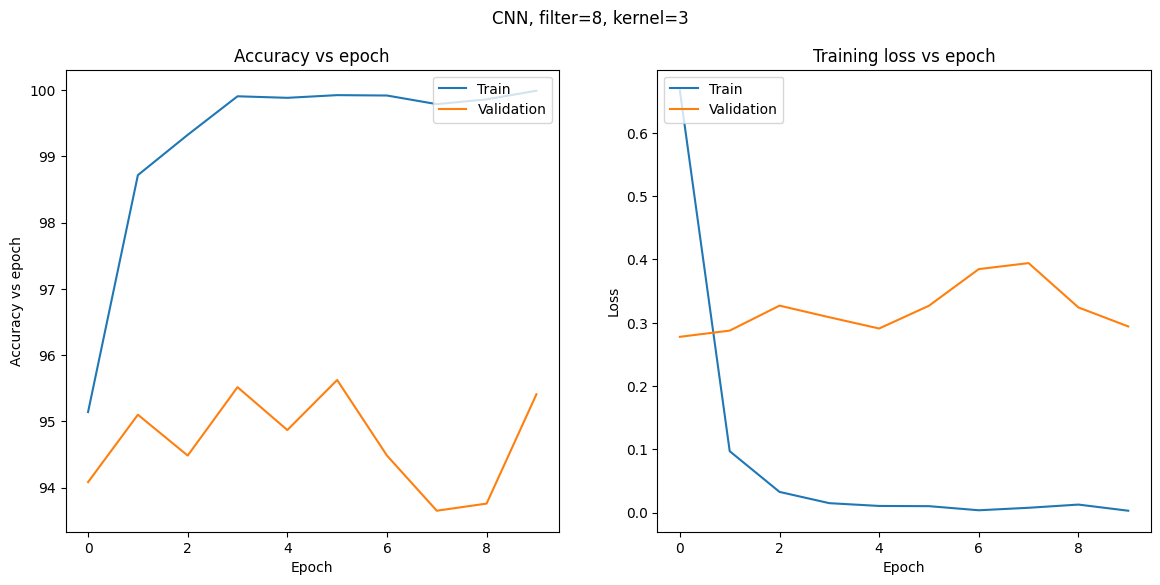

In [ ]:
# Plot training history

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# History for accuracy
ax = plt.subplot(1, 2, 1)
ax.plot(history['train_acc'])
ax.plot(history['val_acc'])
ax.set_title('Accuracy vs epoch')
ax.set_ylabel('Accuracy vs epoch')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper right')

# History for loss
ax = plt.subplot(1, 2, 2)
ax.plot(history['train_loss'])
ax.plot(history['val_loss'])
ax.set_title('Training loss vs epoch')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper left')

fig.suptitle("CNN, filter=8, kernel=3")
plt.show()

100%|██████████| 13/13 [00:01<00:00, 10.24it/s]


(6491,)
Test error: 4.6%


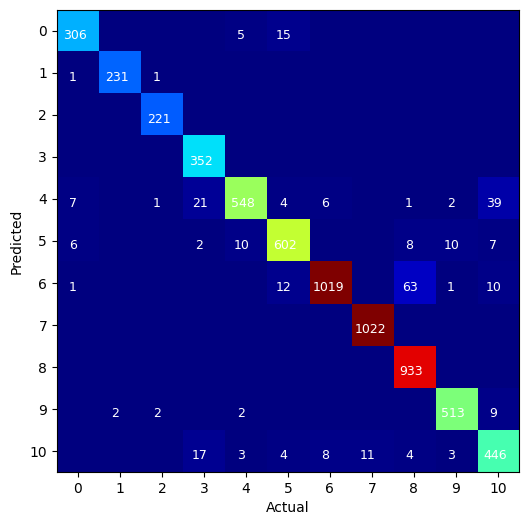

In [ ]:
# Model predictions and confusion matrix
val_predictions, val_labels = get_predictions(model, DataLoader(val_data, batch_size=512, shuffle=True), device)

# Updated call with num_classes
val_error, val_conf_mat = calc_error(val_predictions, val_labels, num_classes=11)
print('Test error: %.1f%%' % val_error)

plt.figure(figsize=(6, 6))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(False)
plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.imshow(val_conf_mat, cmap=plt.cm.jet, interpolation='nearest');

for i, cas in enumerate(val_conf_mat):
    for j, count in enumerate(cas):
        if count > 0:
            xoff = .07 * len(str(count))
            plt.text(j-xoff, i+.2, int(count), fontsize=9, color='white')


##### Filter=8; Kernel=5; Epoch=10

In [ ]:
# Set the random seed for reproducibility
seed = 42
torch.manual_seed(seed)

model2 = CNN(input_size=28, num_filters=8, kernel_size=5)
model2.to(device)
optimizer = optim.Adam(model2.parameters(), lr=0.005)

# Train and evaluate the model
start_time = time.time()
history2 = train(model2, optimizer, train_data, val_data, num_epochs=10)
end_time = time.time()

print(f"\nTraining Time: {end_time - start_time:.2f} seconds")

# Save model and history
torch.save(model2.state_dict(), 'drive/MyDrive/COMP551_A3/3.6_model_filter_8_kernel_5.pth')

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_8_kernel_5.pkl', 'wb')
pickle.dump(history2, fobj)
fobj.close()

print(f"Final Train Accuracy: {history2['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history2['val_acc'][-1]:.2f}%")

100%|██████████| 68/68 [00:08<00:00,  7.56it/s]


Total samples: 34561, Correct predictions: 6164
Total samples: 6491, Correct predictions: 1033
Epoch [1/10], Loss: 2.3869,Train Acc: 17.84%, Val Acc: 15.91%


100%|██████████| 13/13 [00:01<00:00, 10.30it/s]


Total samples: 34561, Correct predictions: 6164
Total samples: 6491, Correct predictions: 1033


100%|██████████| 68/68 [00:09<00:00,  7.41it/s]


...

Total samples: 34561, Correct predictions: 34325
Total samples: 6491, Correct predictions: 5645


100%|██████████| 68/68 [00:08<00:00,  7.64it/s]


Total samples: 34561, Correct predictions: 34379
Total samples: 6491, Correct predictions: 5705
Epoch [10/10], Loss: 0.0271,Train Acc: 99.47%, Val Acc: 87.89%


100%|██████████| 13/13 [00:01<00:00,  8.75it/s]


Total samples: 34561, Correct predictions: 34379
Total samples: 6491, Correct predictions: 5705
Training complete!

Training Time: 268.71 seconds
Final Train Accuracy: 99.47%
Final Validation Accuracy: 87.89%


In [ ]:
model2 = CNN(input_size=28, num_filters=8, kernel_size=5)
model2.to(device)
model2.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_8_kernel_5.pth', map_location=torch.device(device)))
model2.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_8_kernel_5.pkl', 'rb')
history2 = pickle.load(fobj)
fobj.close()

<ipython-input-29-888b37bf0cf2>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model2.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_8_kernel_5.pth'

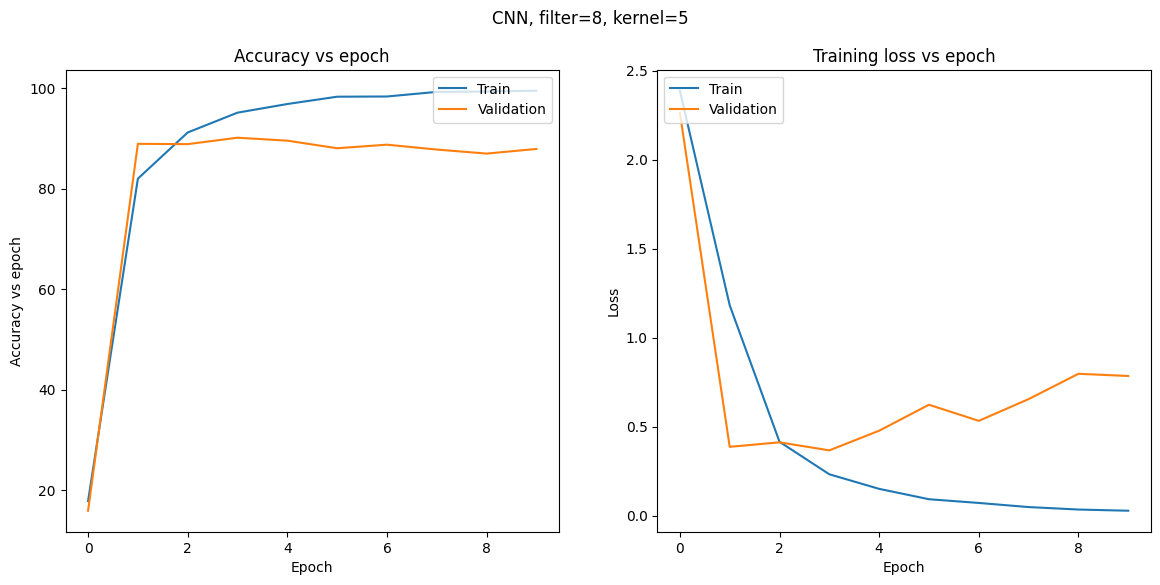

In [ ]:
# Plot training history

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# History for accuracy
ax = plt.subplot(1, 2, 1)
ax.plot(history2['train_acc'])
ax.plot(history2['val_acc'])
ax.set_title('Accuracy vs epoch')
ax.set_ylabel('Accuracy vs epoch')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper right')

# History for loss
ax = plt.subplot(1, 2, 2)
ax.plot(history2['train_loss'])
ax.plot(history2['val_loss'])
ax.set_title('Training loss vs epoch')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper left')

fig.suptitle("CNN, filter=8, kernel=5")
plt.show()

100%|██████████| 13/13 [00:01<00:00,  8.85it/s]


(6491,)
Test error: 12.1%


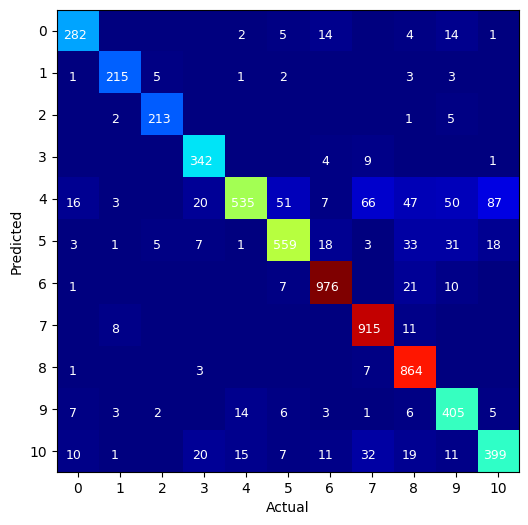

In [ ]:
# Model predictions and confusion matrix
val_predictions2, val_labels2 = get_predictions(model2, DataLoader(val_data, batch_size=512, shuffle=True), device)

# Updated call with num_classes
val_error2, val_conf_mat2 = calc_error(val_predictions2, val_labels2, num_classes=11)
print('Test error: %.1f%%' % val_error2)

plt.figure(figsize=(6, 6))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(False)
plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.imshow(val_conf_mat2, cmap=plt.cm.jet, interpolation='nearest');

for i, cas in enumerate(val_conf_mat2):
    for j, count in enumerate(cas):
        if count > 0:
            xoff = .07 * len(str(count))
            plt.text(j-xoff, i+.2, int(count), fontsize=9, color='white')

##### Filter=3; Kernel=3; Epoch=10

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple M-series chip GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

# Set the random seed for reproducibility
seed = 42
torch.manual_seed(seed)

model7 = CNN(input_size=28, num_filters=3, kernel_size=3)
model7.to(device)
optimizer = optim.Adam(model7.parameters(), lr=0.005)

# Train and evaluate the model
start_time = time.time()
history7 = train(model7, optimizer, train_data, val_data, num_epochs=10)
end_time = time.time()

print(f"\nTraining Time: {end_time - start_time:.2f} seconds")

# Save model and history
torch.save(model7.state_dict(), 'drive/MyDrive/COMP551_A3/3.6_model_filter_3_kernel_3.pth')

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_3_kernel_3.pkl', 'wb')
pickle.dump(history7, fobj)
fobj.close()

print(f"Final Train Accuracy: {history7['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history7['val_acc'][-1]:.2f}%")

cuda


100%|██████████| 68/68 [00:08<00:00,  8.02it/s]


Total samples: 34561, Correct predictions: 31407
Total samples: 6491, Correct predictions: 6134
Epoch [1/10], Loss: 0.7783,Train Acc: 90.87%, Val Acc: 94.50%


100%|██████████| 13/13 [00:01<00:00, 10.45it/s]


Total samples: 34561, Correct predictions: 31407
Total samples: 6491, Correct predictions: 6134


...

Total samples: 34561, Correct predictions: 34561
Total samples: 6491, Correct predictions: 6189


100%|██████████| 68/68 [00:08<00:00,  7.87it/s]


Total samples: 34561, Correct predictions: 34561
Total samples: 6491, Correct predictions: 6197
Epoch [10/10], Loss: 0.0003,Train Acc: 100.00%, Val Acc: 95.47%


100%|██████████| 13/13 [00:01<00:00,  7.86it/s]


Total samples: 34561, Correct predictions: 34561
Total samples: 6491, Correct predictions: 6197
Training complete!

Training Time: 262.74 seconds
Final Train Accuracy: 100.00%
Final Validation Accuracy: 95.47%


In [ ]:
model7 = CNN(input_size=28, num_filters=3, kernel_size=3)
model7.to(device)
model7.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_3_kernel_3.pth', map_location=torch.device(device)))
model7.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_3_kernel_3.pkl', 'rb')
history7 = pickle.load(fobj)
fobj.close()

<ipython-input-30-5f19105ccadf>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model7.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_3_kernel_3.pth'

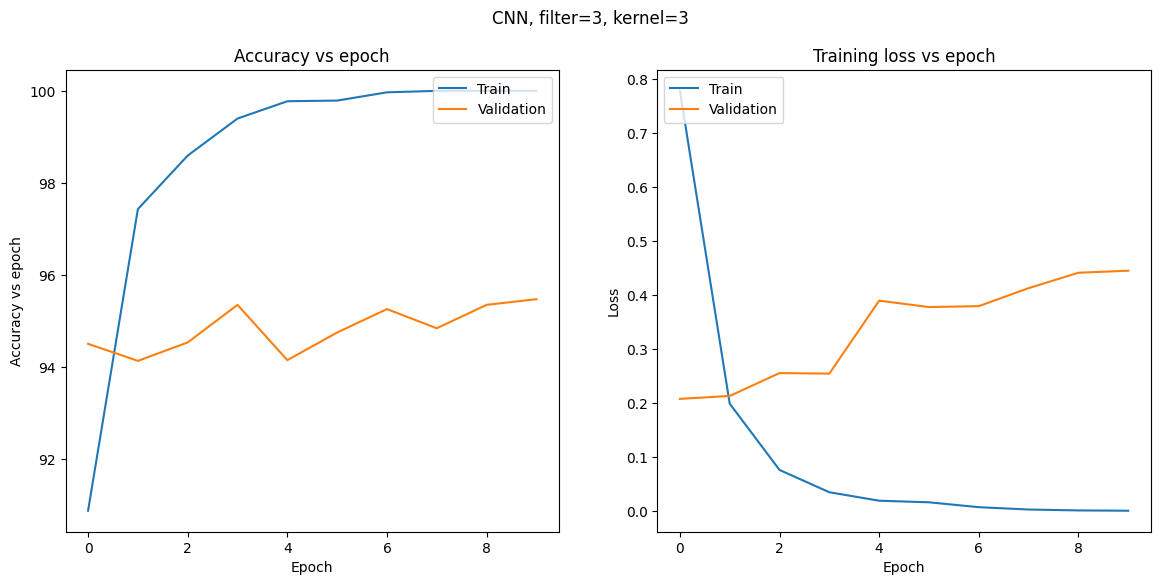

In [ ]:
# Plot training history

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# History for accuracy
ax = plt.subplot(1, 2, 1)
ax.plot(history7['train_acc'])
ax.plot(history7['val_acc'])
ax.set_title('Accuracy vs epoch')
ax.set_ylabel('Accuracy vs epoch')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper right')

# History for loss
ax = plt.subplot(1, 2, 2)
ax.plot(history7['train_loss'])
ax.plot(history7['val_loss'])
ax.set_title('Training loss vs epoch')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper left')

fig.suptitle("CNN, filter=3, kernel=3")
plt.show()

100%|██████████| 13/13 [00:01<00:00,  9.82it/s]


(6491,)
Test error: 4.5%


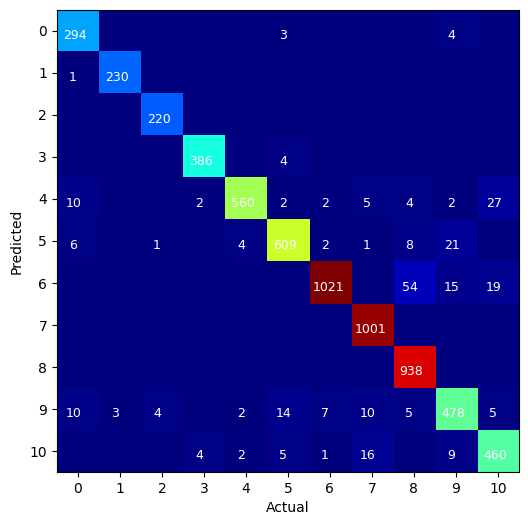

In [ ]:
# Model predictions and confusion matrix
val_predictions, val_labels = get_predictions(model7, DataLoader(val_data, batch_size=512, shuffle=True), device)

# Updated call with num_classes
val_error, val_conf_mat = calc_error(val_predictions, val_labels, num_classes=11)
print('Test error: %.1f%%' % val_error)

plt.figure(figsize=(6, 6))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(False)
plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.imshow(val_conf_mat, cmap=plt.cm.jet, interpolation='nearest');

for i, cas in enumerate(val_conf_mat):
    for j, count in enumerate(cas):
        if count > 0:
            xoff = .07 * len(str(count))
            plt.text(j-xoff, i+.2, int(count), fontsize=9, color='white')


##### Filter=3; Kernel=5; Epoch=10

In [ ]:
# Set the random seed for reproducibility
seed = 42
torch.manual_seed(seed)

model8 = CNN(input_size=28, num_filters=3, kernel_size=5)
model8.to(device)
optimizer = optim.Adam(model8.parameters(), lr=0.005)

# Train and evaluate the model
start_time = time.time()
history8 = train(model8, optimizer, train_data, val_data, num_epochs=10)
end_time = time.time()

print(f"\nTraining Time: {end_time - start_time:.2f} seconds")

# Save model and history
torch.save(model8.state_dict(), 'drive/MyDrive/COMP551_A3/3.6_model_filter_3_kernel_5.pth')

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_3_kernel_5.pkl', 'wb')
pickle.dump(history8, fobj)
fobj.close()

print(f"Final Train Accuracy: {history8['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history8['val_acc'][-1]:.2f}%")

100%|██████████| 68/68 [00:08<00:00,  8.04it/s]


Total samples: 34561, Correct predictions: 30558
Total samples: 6491, Correct predictions: 5834
Epoch [1/10], Loss: 0.7960,Train Acc: 88.42%, Val Acc: 89.88%


100%|██████████| 13/13 [00:01<00:00,  9.25it/s]


Total samples: 34561, Correct predictions: 30558
Total samples: 6491, Correct predictions: 5834


100%|██████████| 68/68 [00:08<00:00,  7.96it/s]


...

Total samples: 34561, Correct predictions: 34329
Total samples: 6491, Correct predictions: 5837


100%|██████████| 68/68 [00:08<00:00,  7.80it/s]


Total samples: 34561, Correct predictions: 34470
Total samples: 6491, Correct predictions: 6116
Epoch [10/10], Loss: 0.0565,Train Acc: 99.74%, Val Acc: 94.22%


100%|██████████| 13/13 [00:01<00:00,  6.56it/s]


Total samples: 34561, Correct predictions: 34470
Total samples: 6491, Correct predictions: 6116
Training complete!

Training Time: 264.92 seconds
Final Train Accuracy: 99.74%
Final Validation Accuracy: 94.22%


In [ ]:
model8 = CNN(input_size=28, num_filters=3, kernel_size=5)
model8.to(device)
model8.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_3_kernel_5.pth', map_location=torch.device(device)))
model8.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_3_kernel_5.pkl', 'rb')
history8 = pickle.load(fobj)
fobj.close()

<ipython-input-31-493a4b2211cb>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model8.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_3_kernel_5.pth'

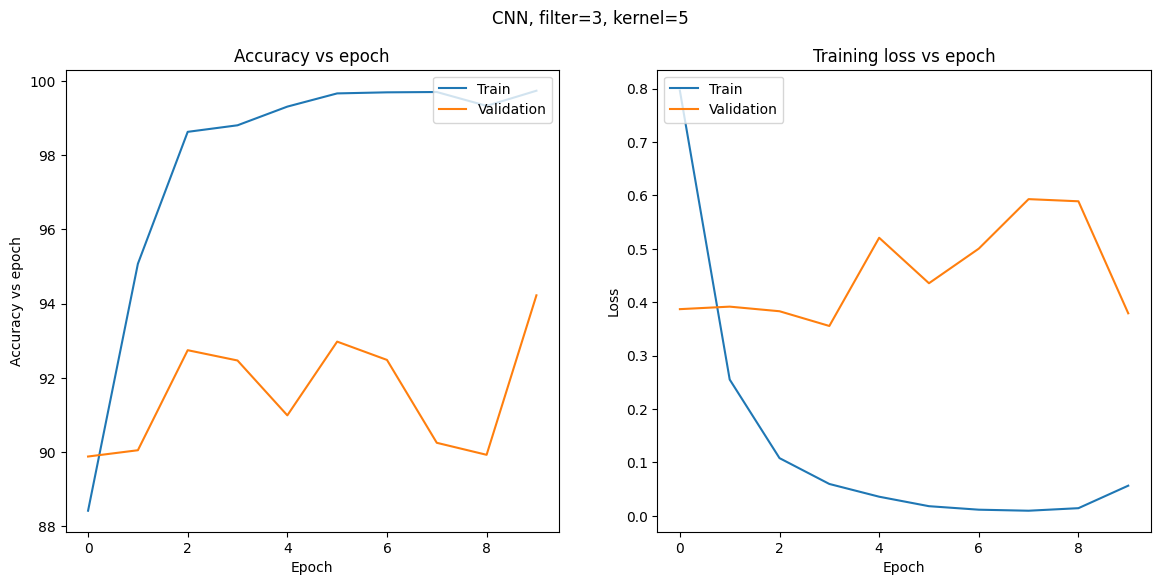

In [ ]:
# Plot training history

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# History for accuracy
ax = plt.subplot(1, 2, 1)
ax.plot(history8['train_acc'])
ax.plot(history8['val_acc'])
ax.set_title('Accuracy vs epoch')
ax.set_ylabel('Accuracy vs epoch')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper right')

# History for loss
ax = plt.subplot(1, 2, 2)
ax.plot(history8['train_loss'])
ax.plot(history8['val_loss'])
ax.set_title('Training loss vs epoch')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper left')

fig.suptitle("CNN, filter=3, kernel=5")
plt.show()

100%|██████████| 13/13 [00:01<00:00,  9.69it/s]


(6491,)
Test error: 5.8%


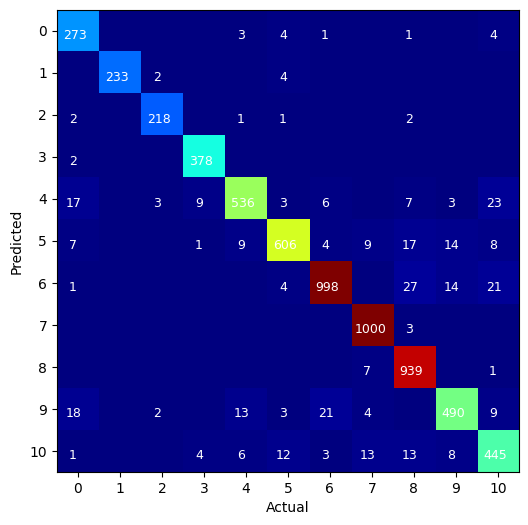

In [ ]:
# Model predictions and confusion matrix
val_predictions8, val_labels8 = get_predictions(model8, DataLoader(val_data, batch_size=512, shuffle=True), device)

# Updated call with num_classes
val_error8, val_conf_mat8 = calc_error(val_predictions8, val_labels8, num_classes=11)
print('Test error: %.1f%%' % val_error8)

plt.figure(figsize=(6, 6))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(False)
plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.imshow(val_conf_mat8, cmap=plt.cm.jet, interpolation='nearest');

for i, cas in enumerate(val_conf_mat8):
    for j, count in enumerate(cas):
        if count > 0:
            xoff = .07 * len(str(count))
            plt.text(j-xoff, i+.2, int(count), fontsize=9, color='white')

#### Choosing the best configuration

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple M-series chip GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

cpu


In [ ]:
# Load all models

model = CNN(input_size=28, num_filters=8, kernel_size=3)
model.to(device)
model.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_8_kernel_3.pth', map_location=torch.device(device)))
model.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_8_kernel_3.pkl', 'rb')
history = pickle.load(fobj)
fobj.close()

model2 = CNN(input_size=28, num_filters=8, kernel_size=5)
model2.to(device)
model2.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_8_kernel_5.pth', map_location=torch.device(device)))
model2.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_8_kernel_5.pkl', 'rb')
history2 = pickle.load(fobj)
fobj.close()

model7 = CNN(input_size=28, num_filters=3, kernel_size=3)
model7.to(device)
model7.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_3_kernel_3.pth', map_location=torch.device(device)))
model7.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_3_kernel_3.pkl', 'rb')
history7 = pickle.load(fobj)
fobj.close()

model8 = CNN(input_size=28, num_filters=3, kernel_size=5)
model8.to(device)
model8.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_3_kernel_5.pth', map_location=torch.device(device)))
model8.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.6_history_filter_3_kernel_5.pkl', 'rb')
history8 = pickle.load(fobj)
fobj.close()

<ipython-input-24-80cdbb9bb0fd>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.6_model_filter_8_kernel_3.pth',

In [ ]:
def get_best_index_from_history(history_list):
    final_val_loss = []
    for history in history_list:
        final_val_loss.append(history['val_loss'][-1])

    return np.argmin(np.array(final_val_loss))


all_cnn_histories = [history, history2, history7, history8]
all_cnn_models = [model, model2, model7, model8]


best_index_3_6 = get_best_index_from_history(all_cnn_histories)
print(best_index_3_6)

0


So the configuration that minimizes the final validation loss is the CNN using a kernel of size 3 with 8 filters.

##### Train and validation loss vs epoch

Text(0.5, 1.0, 'Training and Validation Loss Over Epochs')

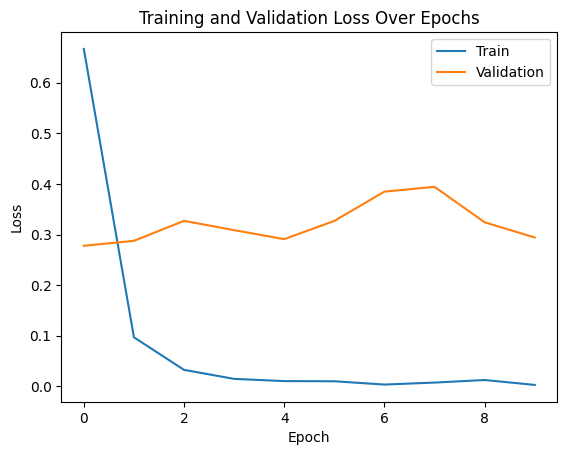

In [ ]:
best_model_3_6 = all_cnn_models[best_index_3_6]
best_model_history_3_6 = all_cnn_histories[best_index_3_6]

plt.plot(np.arange(len(best_model_history_3_6['train_loss'])), best_model_history_3_6['train_loss'], label='Train')
plt.plot(np.arange(len(best_model_history_3_6['val_loss'])), best_model_history_3_6['val_loss'], label='Validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')

##### Test accuracy

In [ ]:
test_loader = DataLoader(test_data, batch_size=512, shuffle=True)
test_acc_3_6 = compute_accuracy(best_model_3_6, test_loader, device)
print(f"Test Accuracy: {test_acc_3_6:.2f}%")

Total samples: 17778, Correct predictions: 15016
Test Accuracy: 84.46%


In [ ]:
# Retrieve results from 3.5
fobj = open(f'drive/MyDrive/COMP551_A3/3.5_results.pkl', 'rb')
results = pickle.load(fobj)
fobj.close()

# Save results from 3.6
results_3_6 = (best_model_history_3_6['train_acc'][-1]/100,
                                      best_model_history_3_6['val_acc'][-1]/100,
                                      test_acc_3_6/100)

results["CNN, filter=8, kernel=3"] = results_3_6

fobj = open(f'drive/MyDrive/COMP551_A3/3.6_results.pkl', 'wb')
pickle.dump(results, fobj)
fobj.close()

In [ ]:
print(results)

{'No Hidden Layers': (0.7693643123752206, 0.8283777538129719, 0.6125548430644617), 'Single Hidden Layer': (0.9028095251873499, 0.892158373132029, 0.699628754640567), 'Two Hidden Layers': (0.9318017418477474, 0.9014019411492836, 0.7045786927663404), 'Two Hidden Layers (Tanh)': (0.9942709991030352, 0.9020181790171006, 0.7068849139385758), 'Two Hidden Layers (Leaky-ReLU)': (0.9311941205404937, 0.9021722384840548, 0.7044099448756891), 'Two Hidden Layers (ReLU + L1)': (0.9976852521628425, 0.9157294715760284, 0.7431094611317358), 'Two Hidden Layers (ReLU + L2)': (0.9632533780851249, 0.9359112617470343, 0.7456406794915064), 'Two Hidden Layers (Unnormalized)': (0.8008738173085269, 0.8940070867354799, 0.6616042299471256), 'Two Hidden Layers (128x128 pixels)': array([0.99589132, 0.92558928, 0.7438407 ]), 'CNN, filter=8, kernel=3': (99.98842626081421, 95.40902788476352, 0.8446394420069749)}


In [ ]:
# Set a seed for reproducibility
set_seed(42)

# Calculate the mean and standard deviation for OrganAMNIST, size=128
mean128, std128 = mean_var_calc('OrganAMNIST', size=128)
print("Calculated Mean:", mean128)
print("Calculated Standard Deviation:", std128)

transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean128], std=[std128])   # Normalize using calculated mean and std
])

100%|██████████| 708M/708M [00:36<00:00, 19.4MB/s]


Calculated Mean: 0.46803364157676697
Calculated Standard Deviation: 0.28756338357925415


In [ ]:
# Load OrganAMNIST dataset (train, validation, and test datasets with transformations)
train_data128 = OrganAMNIST(split="train", transform=transforms, download=True, size=128)
val_data128 = OrganAMNIST(split="val", transform=transforms, download=True, size=128)
test_data128 = OrganAMNIST(split="test", transform=transforms, download=True, size=128)

# Create DataLoaders for each split
batch_size = 512
train_loader128 = DataLoader(train_data128, batch_size=batch_size, shuffle=True)
val_loader128 = DataLoader(val_data128, batch_size=batch_size, shuffle=True)

print(f"{len(train_data128)=}")
print(f"{len(test_data128)=}")

img, label = train_data128[0]
print(f"{img.shape=}")
print(f"{label=}")

Using downloaded and verified file: /root/.medmnist/organamnist_128.npz
Using downloaded and verified file: /root/.medmnist/organamnist_128.npz
Using downloaded and verified file: /root/.medmnist/organamnist_128.npz
len(train_data128)=34561
len(test_data128)=17778
img.shape=torch.Size([1, 128, 128])
label=array([6])


In [ ]:
class CNN128(nn.Module):
    def __init__(self, input_size, num_filters, kernel_size, num_classes=11, batch_size=256, stride=1, padding=1):   # grid search over num_filters and kernel_size
        super().__init__()
        self.model = nn.Sequential()
        self.model.append(nn.Conv2d(1, num_filters, kernel_size, stride, padding))
        self.model.append(nn.ReLU())

        output1_size = int((input_size - kernel_size + 2*padding)/stride) + 1

        self.model.append(nn.Conv2d(num_filters, num_filters, kernel_size, stride, padding))
        self.model.append(nn.ReLU())

        output2_size = int((output1_size - kernel_size + 2*padding)/stride) + 1
        flattened_size = int(output2_size * output2_size * num_filters)

        self.model.append(nn.Flatten())
        self.model.append(nn.Linear(flattened_size, 512))
        self.model.append(nn.ReLU())
        self.model.append(nn.Linear(512, 256))
        self.model.append(nn.ReLU())
        self.model.append(nn.Linear(256, num_classes)) # output layer

    def forward(self, x):
        return self.model(x)

In [ ]:
def compute_accuracy128(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculation for evaluation
        for images, labels in data_loader:
            images = images.view(-1, 1, 128, 128)
            images, labels = images.to(device), labels.to(device)

            # Flatten labels to ensure correct shape
            labels = labels.view(-1)

            # Forward pass
            outputs = model(images)  # Get logits
            _, predicted = torch.max(outputs, 1)  # Get predicted class indices

            # Ensure correct and total are correctly accumulated
            correct += (predicted == labels).sum().item()
            total += labels.size(0)  # Total number of labels in the batch

    print(f"Total samples: {total}, Correct predictions: {correct}")

    accuracy = correct / total * 100  # Convert to percentage
    return accuracy

In [ ]:
def train128(model, optimizer, train_dataset, val_dataset, num_epochs):

    train_loader128 = DataLoader(train_data128, batch_size=512, shuffle=True)
    val_loader128 = DataLoader(val_data128, batch_size=512, shuffle=True)

    # Define the loss function
    criterion = nn.CrossEntropyLoss()

    # Training loop
    history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_loss": []}

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0

        for images, labels in tqdm(train_loader128):
            images = images.view(-1, 1, 128, 128)

            # Ensure labels are 1D
            labels = labels.view(-1)

            # Move tensors to the configured device (GPU or CPU)
            images, labels = images.to(device), labels.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Compute metrics
        train_acc128 = compute_accuracy128(model, train_loader128, device)
        val_acc128 = compute_accuracy128(model, val_loader128, device)

        # Compute validation error
        val_loss = 0
        model.eval()  # Set model to evaluation mode

        with torch.no_grad():
            for images, labels in tqdm(val_loader128):
                images = images.view(-1, 1, 128, 128)

                # Ensure labels are 1D
                labels = labels.view(-1)

                # Move tensors to the configured device (GPU or CPU)
                images, labels = images.to(device), labels.to(device)

                # Forward pass
                outputs = model(images)

                # Calculate loss
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_loss = val_loss/len(val_loader128.dataset)
        loss = running_loss/len(train_loader128.dataset)
        history["val_loss"].append(val_loss)
        history["train_loss"].append(loss)
        history["train_acc"].append(train_acc128)
        history["val_acc"].append(val_acc128)

        # Print the average loss for the epoch
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f},'
              f"Train Acc: {train_acc128:.2f}%, Val Acc: {val_acc128:.2f}%")

    print('Training complete!')
    return history

#### Training

##### Filter=8; Kernel=3; Epoch=10

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple M-series chip GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

cuda


In [ ]:
model3 = CNN128(input_size=128, num_filters=8, kernel_size=3)
model3.to(device)

optimizer = optim.Adam(model3.parameters(), lr=0.005)

# Set the random seed for reproducibility
seed = 42
torch.manual_seed(seed)

# Train and evaluate the model
start_time = time.time()
history3 = train128(model3, optimizer, train_data128, val_data128, num_epochs=10)
end_time = time.time()

print(f"\nTraining Time: {end_time - start_time:.2f} seconds")

# Save model and history
torch.save(model3.state_dict(), 'drive/MyDrive/COMP551_A3/3.7_model_kernel_3.pth')

fobj = open('drive/MyDrive/COMP551_A3/3.7_history_kernel_3.pkl', 'wb')
pickle.dump(history3, fobj)
fobj.close()

print(f"Final Train Accuracy: {history3['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history3['val_acc'][-1]:.2f}%")

100%|██████████| 68/68 [00:24<00:00,  2.78it/s]


Total samples: 34561, Correct predictions: 29677
Total samples: 6491, Correct predictions: 5624


100%|██████████| 13/13 [00:03<00:00,  4.30it/s]


Epoch [1/10], Loss: 0.0048,Train Acc: 85.87%, Val Acc: 86.64%


100%|██████████| 68/68 [00:21<00:00,  3.15it/s]


...

Epoch [9/10], Loss: 0.0000,Train Acc: 99.82%, Val Acc: 91.23%


100%|██████████| 68/68 [00:21<00:00,  3.19it/s]


Total samples: 34561, Correct predictions: 34534
Total samples: 6491, Correct predictions: 5947


100%|██████████| 13/13 [00:03<00:00,  3.47it/s]


Epoch [10/10], Loss: 0.0000,Train Acc: 99.92%, Val Acc: 91.62%
Training complete!

Training Time: 418.04 seconds
Final Train Accuracy: 99.92%
Final Validation Accuracy: 91.62%


In [ ]:
# Load model

model3 = CNN128(input_size=128, num_filters=8, kernel_size=3)
model3.to(device)
model3.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.7_model_kernel_3.pth', map_location=torch.device(device)))
model3.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.7_history_kernel_3.pkl', 'rb')
history3 = pickle.load(fobj)
fobj.close()

<ipython-input-15-62029bc52bc5>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model3.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.7_model_kernel_3.pth', map_loc

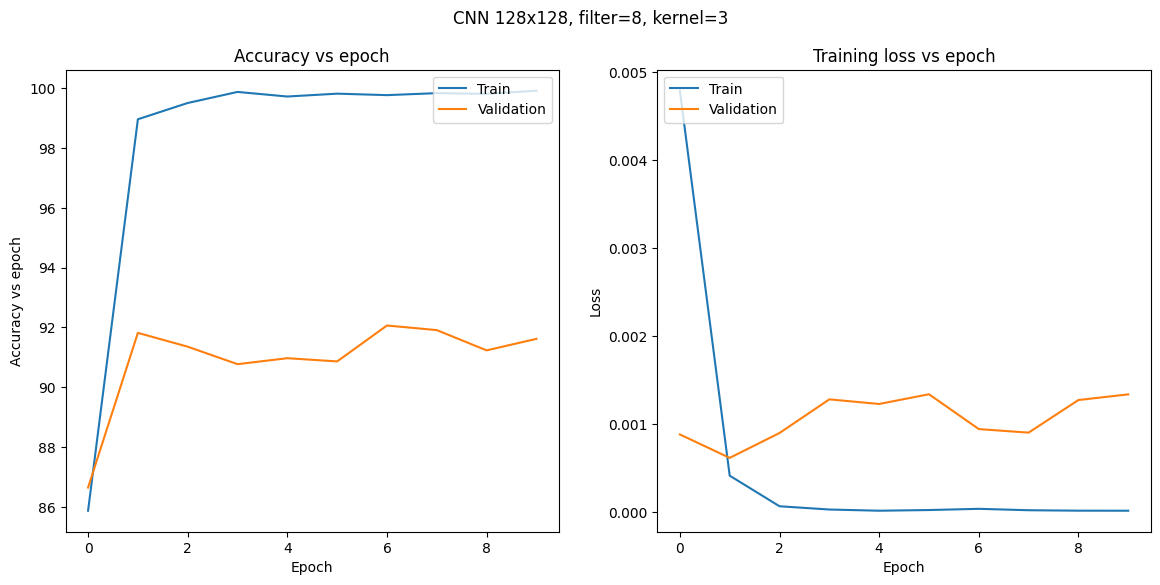

In [ ]:
# Plot training history

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# History for accuracy
ax = plt.subplot(1, 2, 1)
ax.plot(history3['train_acc'])
ax.plot(history3['val_acc'])
ax.set_title('Accuracy vs epoch')
ax.set_ylabel('Accuracy vs epoch')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper right')

# History for loss
ax = plt.subplot(1, 2, 2)
ax.plot(history3['train_loss'])
ax.plot(history3['val_loss'])
ax.set_title('Training loss vs epoch')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper left')

fig.suptitle("CNN 128x128, filter=8, kernel=3")
plt.show()

In [ ]:
def get_predictions128(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            labels = labels.view(-1)
            images = images.view(-1, 1, 128, 128)
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)  # Get logits
            _, predicted = torch.max(outputs.data, 1)  # Get predicted class indices

            all_predictions.append(predicted.cpu().numpy())     # Append predictions to list
            all_labels.append(labels.cpu().numpy())             # Append true labels to list

    # Concatenate all predictions and labels into single numpy arrays
    return np.concatenate(all_predictions), np.concatenate(all_labels)

100%|██████████| 13/13 [00:02<00:00,  4.94it/s]


(6491,)
Validation error: 8.4%


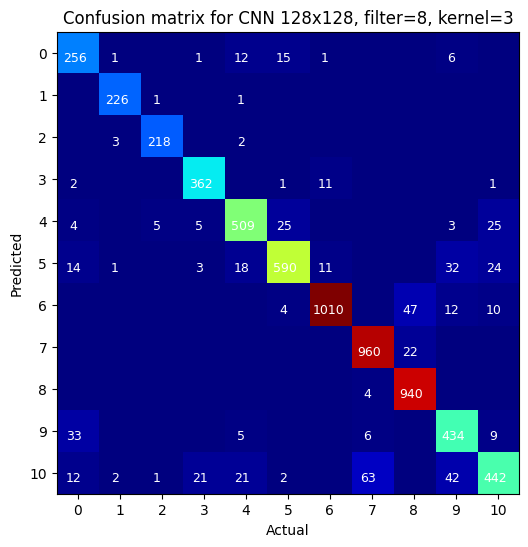

In [ ]:
# Model predictions and confusion matrix
val_predictions_3, val_labels_3 = get_predictions128(model3, DataLoader(val_data128, batch_size=512, shuffle=True), device)

# Updated call with num_classes
val_error_3, val_conf_mat = calc_error(val_predictions_3, val_labels_3, num_classes=11)
print('Validation error: %.1f%%' % val_error_3)

num_classes = 11

plt.figure(figsize=(6, 6))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(False)
plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.title("Confusion matrix for CNN 128x128, filter=8, kernel=3")
plt.imshow(val_conf_mat, cmap=plt.cm.jet, interpolation='nearest');

for i, cas in enumerate(val_conf_mat):
    for j, count in enumerate(cas):
        if count > 0:
            xoff = .07 * len(str(count))
            plt.text(j-xoff, i+.2, int(count), fontsize=9, color='white')

##### Filter=8; Kernel=5; Epoch=10

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple M-series chip GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

model4 = CNN128(input_size=128, num_filters=8, kernel_size=5)
model4.to(device)

optimizer = optim.Adam(model4.parameters(), lr=0.001)

# Set the random seed for reproducibility
seed = 42
torch.manual_seed(seed)

# Train and evaluate the model
start_time = time.time()
history4 = train128(model4, optimizer, train_data128, val_data128, num_epochs=10)
end_time = time.time()

print(f"\nTraining Time: {end_time - start_time:.2f} seconds")

# Save model and history
torch.save(model4.state_dict(), 'drive/MyDrive/COMP551_A3/3.7_model_kernel_5.pth')

fobj = open('drive/MyDrive/COMP551_A3/3.7_history_kernel_5.pkl', 'wb')
pickle.dump(history4, fobj)
fobj.close()

print(f"Final Train Accuracy: {history4['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history4['val_acc'][-1]:.2f}%")

cuda


100%|██████████| 68/68 [00:26<00:00,  2.54it/s]


Total samples: 34561, Correct predictions: 29833
Total samples: 6491, Correct predictions: 5916


100%|██████████| 13/13 [00:02<00:00,  4.48it/s]


Epoch [1/10], Loss: 0.0027,Train Acc: 86.32%, Val Acc: 91.14%


...

Epoch [9/10], Loss: 0.0000,Train Acc: 99.79%, Val Acc: 93.16%


100%|██████████| 68/68 [00:24<00:00,  2.74it/s]


Total samples: 34561, Correct predictions: 34541
Total samples: 6491, Correct predictions: 6084


100%|██████████| 13/13 [00:02<00:00,  4.97it/s]


Epoch [10/10], Loss: 0.0000,Train Acc: 99.94%, Val Acc: 93.73%
Training complete!

Training Time: 474.00 seconds
Final Train Accuracy: 99.94%
Final Validation Accuracy: 93.73%


In [ ]:
# Load model
model4 = CNN128(input_size=128, num_filters=8, kernel_size=5)
model4.to(device)
model4.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.7_model_kernel_5.pth', map_location=torch.device(device)))
model4.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.7_history_kernel_5.pkl', 'rb')
history4 = pickle.load(fobj)
fobj.close()

<ipython-input-16-461e8cb6759b>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model4.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.7_model_kernel_5.pth', map_loc

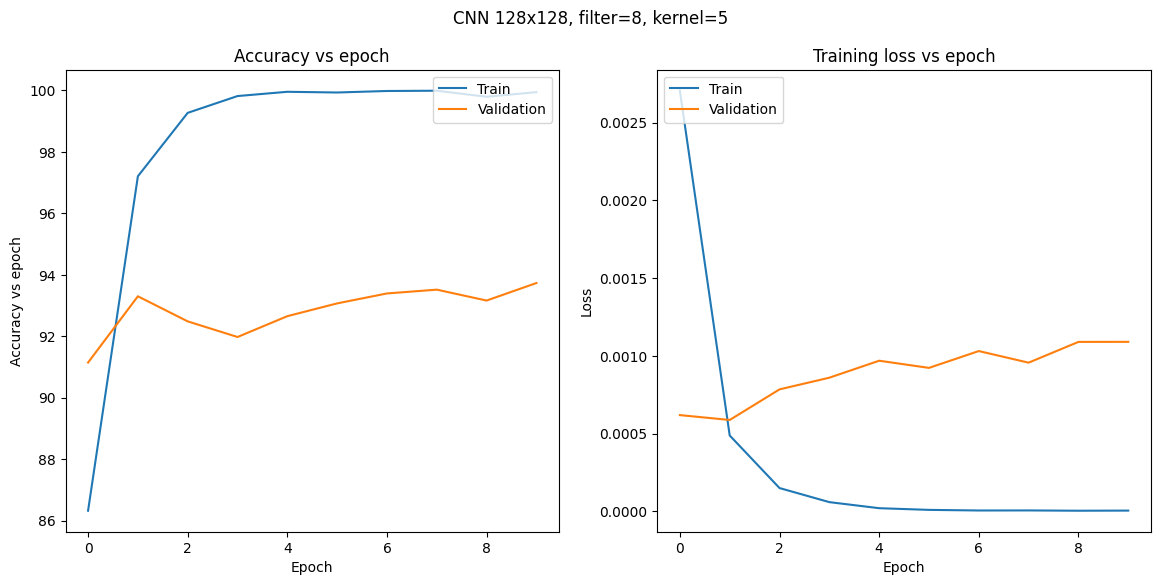

In [ ]:
# Plot training history

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# History for accuracy
ax = plt.subplot(1, 2, 1)
ax.plot(history4['train_acc'])
ax.plot(history4['val_acc'])
ax.set_title('Accuracy vs epoch')
ax.set_ylabel('Accuracy vs epoch')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper right')

# History for loss
ax = plt.subplot(1, 2, 2)
ax.plot(history4['train_loss'])
ax.plot(history4['val_loss'])
ax.set_title('Training loss vs epoch')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper left')

fig.suptitle("CNN 128x128, filter=8, kernel=5")
plt.show()

100%|██████████| 13/13 [00:03<00:00,  4.32it/s]


(6491,)
Validation error: 8.4%


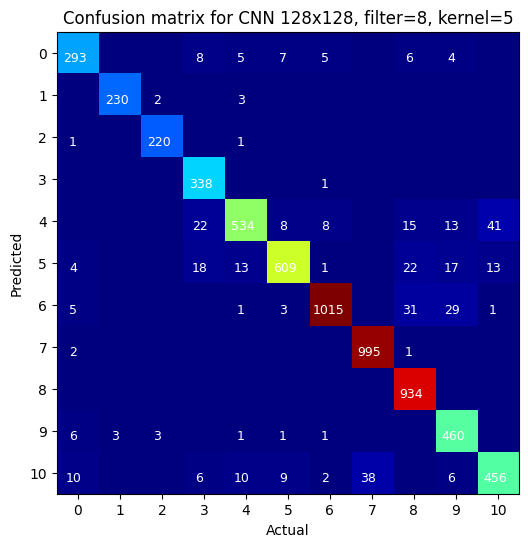

In [ ]:
# Model predictions and confusion matrix
val_predictions_4, val_labels_4 = get_predictions128(model4, DataLoader(val_data128, batch_size=512, shuffle=True), device)

# Updated call with num_classes
val_error_4, val_conf_mat = calc_error(val_predictions_4, val_labels_4, num_classes=11)
print('Validation error: %.1f%%' % val_error_3)

num_classes = 11

plt.figure(figsize=(6, 6))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(False)
plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.title("Confusion matrix for CNN 128x128, filter=8, kernel=5")
plt.imshow(val_conf_mat, cmap=plt.cm.jet, interpolation='nearest');

for i, cas in enumerate(val_conf_mat):
    for j, count in enumerate(cas):
        if count > 0:
            xoff = .07 * len(str(count))
            plt.text(j-xoff, i+.2, int(count), fontsize=9, color='white')

#### Choosing the best configuration

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple M-series chip GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

cpu


In [ ]:
# Load all models

model3 = CNN128(input_size=128, num_filters=8, kernel_size=3)
model3.to(device)
model3.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.7_model_kernel_3.pth', map_location=torch.device(device)))
model3.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.7_history_kernel_3.pkl', 'rb')
history3 = pickle.load(fobj)
fobj.close()

model4 = CNN128(input_size=128, num_filters=8, kernel_size=5)
model4.to(device)
model4.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.7_model_kernel_5.pth', map_location=torch.device(device)))
model4.eval()

fobj = open('drive/MyDrive/COMP551_A3/3.7_history_kernel_5.pkl', 'rb')
history4 = pickle.load(fobj)
fobj.close()

<ipython-input-14-b0bd5ede7463>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model3.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.7_model_kernel_3.pth', map_loc

In [ ]:
def get_best_index_from_history(history_list):
    final_val_loss = []
    for history in history_list:
        final_val_loss.append(history['val_loss'][-1])

    return np.argmin(np.array(final_val_loss))


all_cnn128_histories = [history3, history4]
all_cnn128_models = [model3, model4]

best_index_3_7 = get_best_index_from_history(all_cnn128_histories)
print(best_index_3_7)

1


So the configuration that minimizes the final validation loss is the CNN using a kernel of size 5 with 8 filters.

##### Train and validation loss vs epoch

Text(0.5, 1.0, 'Training and Validation Loss Over Epochs')

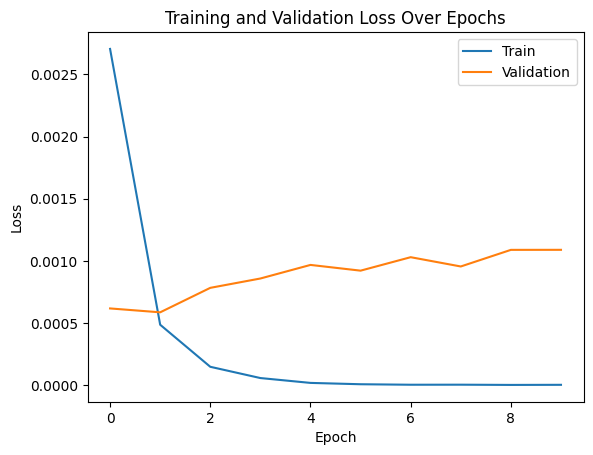

In [ ]:
best_model_3_7 = all_cnn128_models[best_index_3_7]
best_model_history_3_7 = all_cnn128_histories[best_index_3_7]

plt.plot(np.arange(len(best_model_history_3_7['train_loss'])), best_model_history_3_7['train_loss'], label='Train')
plt.plot(np.arange(len(best_model_history_3_7['val_loss'])), best_model_history_3_7['val_loss'], label='Validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')

##### Test accuracy

In [ ]:
test_loader = DataLoader(test_data128, batch_size=512, shuffle=True)
test_acc_3_7 = compute_accuracy128(best_model_3_7, test_loader, device)
print(f"Test Accuracy: {test_acc_3_7:.2f}%")

Total samples: 17778, Correct predictions: 14528
Test Accuracy: 81.72%


In [ ]:
import pandas as pd

# Retrieve results from 3.6
fobj = open(f'drive/MyDrive/COMP551_A3/3.6_results.pkl', 'rb')
results = pickle.load(fobj)
fobj.close()

# Save results from 3.7
results_3_7 = (best_model_history_3_7['train_acc'][-1]/100,
                                      best_model_history_3_7['val_acc'][-1]/100,
                                      test_acc_3_7/100)

results["CNN 128x128, filter=8, kernel=3"] = results_3_7

fobj = open(f'drive/MyDrive/COMP551_A3/3.7_results.pkl', 'wb')
pickle.dump(results, fobj)
fobj.close()

#### Load dataset

In [ ]:
# Set a seed for reproducibility
set_seed(42) #arbitrary seed

# Calculate the mean and standard deviation for OrganAMNIST
mean, std = mean_var_calc('OrganAMNIST', size=128)
print("Calculated Mean:", mean)
print("Calculated Standard Deviation:", std)

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std])]
    )

# Load OrganAMNIST dataset (train, validation, and test datasets with transformations)
train_data = OrganAMNIST(split="train", transform=transform, download=True, size=128)
val_data = OrganAMNIST(split="val", transform=transform, download=True, size=128)
test_data = OrganAMNIST(split="test", transform=transform, download=True, size=128)

# Create DataLoaders for each split
batch_size = 512
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"{len(train_data)=}")
print(f"{len(test_data)=}")

img, label = train_data[0]
print(f"{img.shape=}")
print(f"{label=}")

Using downloaded and verified file: /root/.medmnist/organamnist_128.npz
Calculated Mean: 0.46803364157676697
Calculated Standard Deviation: 0.28756338357925415
Using downloaded and verified file: /root/.medmnist/organamnist_128.npz
Using downloaded and verified file: /root/.medmnist/organamnist_128.npz
Using downloaded and verified file: /root/.medmnist/organamnist_128.npz
len(train_data)=34561
len(test_data)=17778
img.shape=torch.Size([3, 64, 64])
label=array([6])


#### First Architecture

In [ ]:
# Load pretrained model
res_model = torchvision.models.resnet18(pretrained=True)
print(res_model)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Freeze weights and modify fully connected layers

for param in res_model.parameters():
    param.requires_grad = False

res_model.fc = nn.Linear(512, 11)   # change the number of output classes
print(res_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Set device
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple M-series chip GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

res_model.to(device)
print(device)

cuda


##### Training

In [ ]:
def compute_accuracy3_8(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculation for evaluation
        for images, labels in data_loader:
            images = images.view(-1, 3, 64, 64)
            images, labels = images.to(device), labels.to(device)

            # Flatten labels to ensure correct shape
            labels = labels.view(-1)

            # Forward pass
            outputs = model(images)  # Get logits
            _, predicted = torch.max(outputs, 1)  # Get predicted class indices

            # Ensure correct and total are correctly accumulated
            correct += (predicted == labels).sum().item()
            total += labels.size(0)  # Total number of labels in the batch

    print(f"Total samples: {total}, Correct predictions: {correct}")

    accuracy = correct / total * 100  # Convert to percentage
    return accuracy

In [ ]:
def train3_8(model, optimizer, train_dataset, val_dataset, test_dataset, num_epochs):
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=512, shuffle=True)

    # Define the loss function
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "val_acc": [], "test_acc": [], "val_loss": []}

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images = images.view(-1, 3, 64, 64).to(device)  # Reshape for CNN
            labels = labels.view(-1).to(device)  # Flatten labels

            optimizer.zero_grad()  # Clear gradients

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)  # Compute loss

            # Backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Record training loss and accuracy
        train_acc = compute_accuracy3_8(model, train_loader, device)
        val_acc = compute_accuracy3_8(model, val_loader, device)

        # Compute validation error
        val_loss = 0
        model.eval()  # Set model to evaluation mode

        with torch.no_grad():
            for images, labels in tqdm(val_loader):
                # Reshape the images to [batch_size, 3, 64, 64]
                images = images.view(-1, 3, 64, 64)

                # Ensure labels are 1D
                labels = labels.view(-1)

                # Move tensors to the configured device (GPU or CPU)
                images, labels = images.to(device), labels.to(device)

                # Forward pass
                outputs = model(images)

                # Calculate loss
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        history["val_loss"].append(val_loss/len(val_loader))
        history["train_loss"].append(running_loss / len(train_loader))
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}], Training loss: {running_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    print("Training complete!")
    return history

In [ ]:
def get_predictions3_8(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    all_predictions = []
    all_labels = []

    with torch.no_grad():  # Disable gradient calculation for inference
        for images, labels in tqdm(data_loader):
            images = images.view(-1, 3, 64, 64)  # Reshape for CNN
            labels = labels.view(-1)
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)  # Get logits
            _, predicted = torch.max(outputs.data, 1)  # Get predicted class indices

            all_predictions.append(predicted.cpu().numpy())     # Append predictions to list
            all_labels.append(labels.cpu().numpy())             # Append true labels to list

    # Concatenate all predictions and labels into single numpy arrays
    return np.concatenate(all_predictions), np.concatenate(all_labels)

##### Lr = 0.005

In [ ]:
# Train and evaluate the model

optimizer = optim.Adam(res_model.parameters(), lr=0.005)

start_time = time.time()
history = train3_8(res_model, optimizer, train_data, val_data, test_data, num_epochs=10)
end_time = time.time()

print(f"\nTraining Time: {end_time - start_time:.2f} seconds")

# Save model and history
torch.save(res_model.state_dict(), 'drive/MyDrive/COMP551_A3/3.8_model_lr_0.005.pth')

fobj = open('drive/MyDrive/COMP551_A3/3.8_history_lr_0.005.pkl', 'wb')
pickle.dump(history, fobj)
fobj.close()

# Final Results
print(f"Final Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.2f}%")

Epoch 1/10: 100%|██████████| 68/68 [00:23<00:00,  2.89it/s]


Total samples: 34561, Correct predictions: 29751
Total samples: 6491, Correct predictions: 5618


100%|██████████| 13/13 [00:03<00:00,  3.34it/s]


Epoch [1/10], Training loss: 0.7427, Train Acc: 86.08%, Val Acc: 86.55%


Epoch 2/10: 100%|██████████| 68/68 [00:23<00:00,  2.85it/s]


...

Epoch [9/10], Training loss: 0.2423, Train Acc: 92.31%, Val Acc: 88.83%


Epoch 10/10: 100%|██████████| 68/68 [00:24<00:00,  2.81it/s]


Total samples: 34561, Correct predictions: 31916
Total samples: 6491, Correct predictions: 5781


100%|██████████| 13/13 [00:05<00:00,  2.50it/s]

Epoch [10/10], Training loss: 0.2418, Train Acc: 92.35%, Val Acc: 89.06%
Training complete!

Training Time: 540.93 seconds
Final Train Accuracy: 92.35%
Final Validation Accuracy: 89.06%


###### Plots

In [ ]:
# Load model
res_model = torchvision.models.resnet18(pretrained=False)
res_model.fc = nn.Linear(512, 11)
res_model.to(device)

# Load the saved state_dict
res_model.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.8_model_lr_0.005.pth', map_location=torch.device(device)))
res_model.eval()

# Load the saved history
fobj = open('drive/MyDrive/COMP551_A3/3.8_history_lr_0.005.pkl', 'rb')
history = pickle.load(fobj)
fobj.close()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-102-c30a55252ece>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recomme

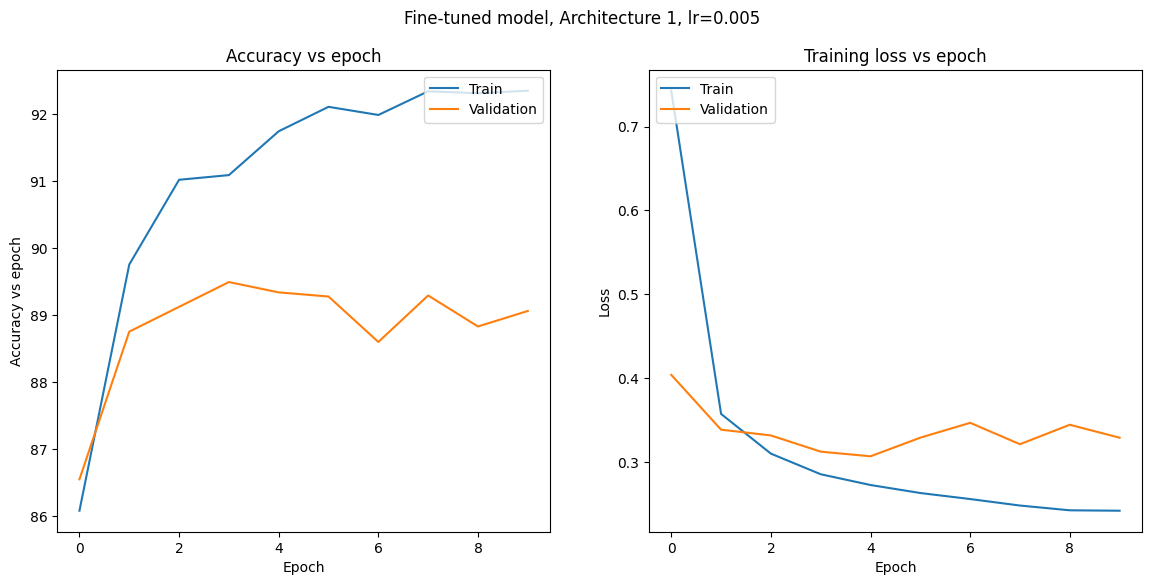

In [ ]:
# Plot training history

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# History for accuracy
ax = plt.subplot(1, 2, 1)
ax.plot(history['train_acc'])
ax.plot(history['val_acc'])
ax.set_title('Accuracy vs epoch')
ax.set_ylabel('Accuracy vs epoch')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper right')

# History for loss
ax = plt.subplot(1, 2, 2)
ax.plot(history['train_loss'])
ax.plot(history['val_loss'])
ax.set_title('Training loss vs epoch')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper left')

fig.suptitle("Fine-tuned model, Architecture 1, lr=0.005")
plt.show()

100%|██████████| 13/13 [00:04<00:00,  3.24it/s]


(6491,)
Validation error: 10.9%


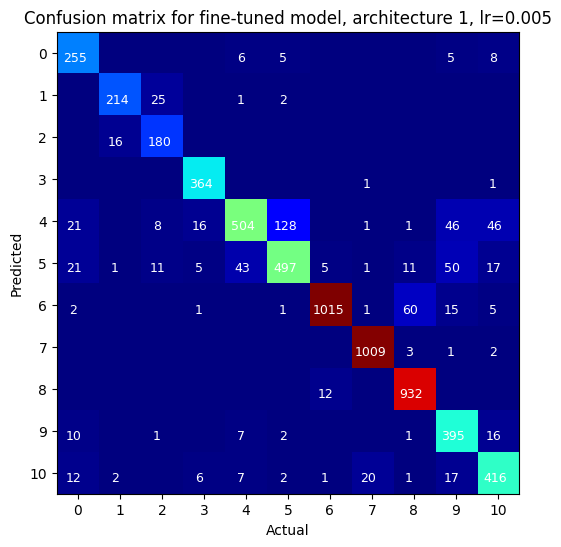

In [ ]:
val_predictions_1, val_labels_1 = get_predictions3_8(res_model, DataLoader(val_data, batch_size=512, shuffle=True), device)

# Updated call with num_classes
val_error_1, val_conf_mat = calc_error(val_predictions_1, val_labels_1, num_classes=11)
print('Validation error: %.1f%%' % val_error_1)

num_classes = 11

plt.figure(figsize=(6, 6))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(False)
plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.title("Confusion matrix for fine-tuned model, architecture 1, lr=0.005")
plt.imshow(val_conf_mat, cmap=plt.cm.jet, interpolation='nearest');

for i, cas in enumerate(val_conf_mat):
    for j, count in enumerate(cas):
        if count > 0:
            xoff = .07 * len(str(count))
            plt.text(j-xoff, i+.2, int(count), fontsize=9, color='white')

##### Lr = 0.001

In [ ]:
res_model_2 = torchvision.models.resnet18(pretrained=True)
for param in res_model_2.parameters():
    param.requires_grad = False

res_model_2.fc = nn.Linear(512, 11)

# Set device
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple M-series chip GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

res_model_2.to(device)
print(device)

cuda


In [ ]:
# Train and evaluate the model, LR=0.001

optimizer_2 = optim.Adam(res_model_2.parameters(), lr=0.001)

start_time = time.time()
history_2 = train3_8(res_model_2, optimizer_2, train_data, val_data, test_data, num_epochs=10)
end_time = time.time()

print(f"\nTraining Time: {end_time - start_time:.2f} seconds")

# Save model and history
torch.save(res_model_2.state_dict(), 'drive/MyDrive/COMP551_A3/3.8_model_lr_0.001.pth')

fobj = open('drive/MyDrive/COMP551_A3/3.8_history_lr_0.001.pkl', 'wb')
pickle.dump(history_2, fobj)
fobj.close()

# Final Results
print(f"Final Train Accuracy: {history_2['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history_2['val_acc'][-1]:.2f}%")

Epoch 1/10: 100%|██████████| 68/68 [00:23<00:00,  2.89it/s]


Total samples: 34561, Correct predictions: 28230
Total samples: 6491, Correct predictions: 5420


100%|██████████| 13/13 [00:03<00:00,  3.25it/s]


Epoch [1/10], Training loss: 1.1715, Train Acc: 81.68%, Val Acc: 83.50%


Epoch 2/10: 100%|██████████| 68/68 [00:23<00:00,  2.95it/s]


...

Epoch [9/10], Training loss: 0.2948, Train Acc: 91.24%, Val Acc: 89.51%


Epoch 10/10: 100%|██████████| 68/68 [00:23<00:00,  2.92it/s]


Total samples: 34561, Correct predictions: 31578
Total samples: 6491, Correct predictions: 5796


100%|██████████| 13/13 [00:04<00:00,  3.23it/s]

Epoch [10/10], Training loss: 0.2859, Train Acc: 91.37%, Val Acc: 89.29%
Training complete!

Training Time: 535.47 seconds
Final Train Accuracy: 91.37%
Final Validation Accuracy: 89.29%


###### Plots

In [ ]:
# Load model
res_model_2 = torchvision.models.resnet18(pretrained=False)
res_model_2.fc = nn.Linear(512, 11)
res_model_2.to(device)

# Load the saved state_dict

res_model_2.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.8_model_lr_0.001.pth', map_location=torch.device(device)))
res_model_2.eval()

# Load the saved history
fobj = open('drive/MyDrive/COMP551_A3/3.8_history_lr_0.001.pkl', 'rb')
history_2 = pickle.load(fobj)
fobj.close()

<ipython-input-107-023c153a70ab>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res_model_2.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.8_model_lr_0.001.pth', m

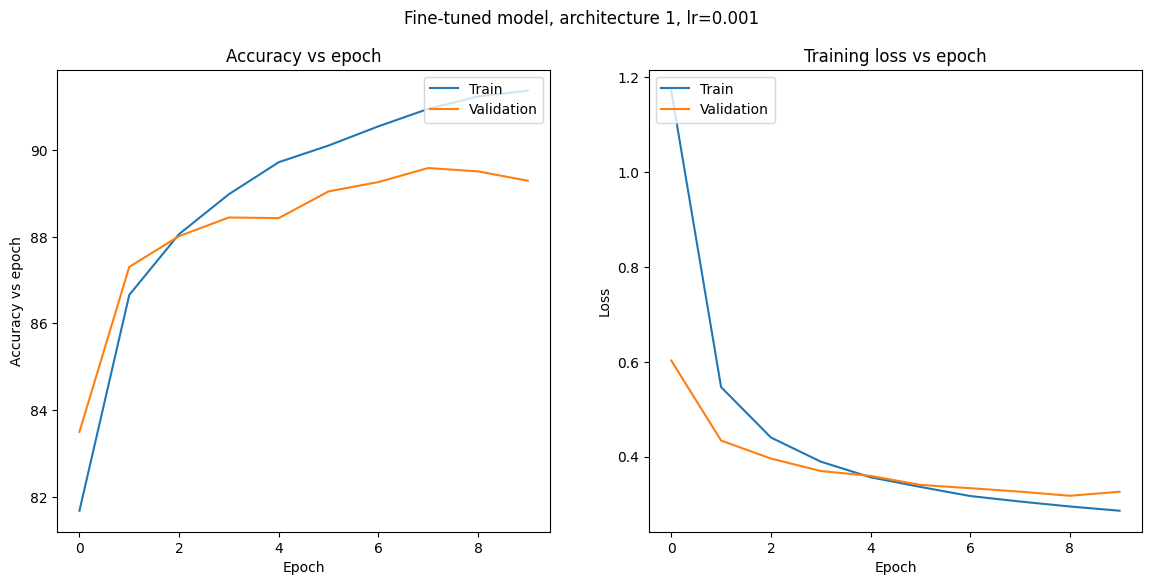

In [ ]:
# Plot training history

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# History for accuracy
ax = plt.subplot(1, 2, 1)
ax.plot(history_2['train_acc'])
ax.plot(history_2['val_acc'])
ax.set_title('Accuracy vs epoch')
ax.set_ylabel('Accuracy vs epoch')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper right')

# History for loss
ax = plt.subplot(1, 2, 2)
ax.plot(history_2['train_loss'])
ax.plot(history_2['val_loss'])
ax.set_title('Training loss vs epoch')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper left')

fig.suptitle("Fine-tuned model, architecture 1, lr=0.001")
plt.show()

100%|██████████| 13/13 [00:05<00:00,  2.54it/s]


(6491,)
Validation error: 10.7%


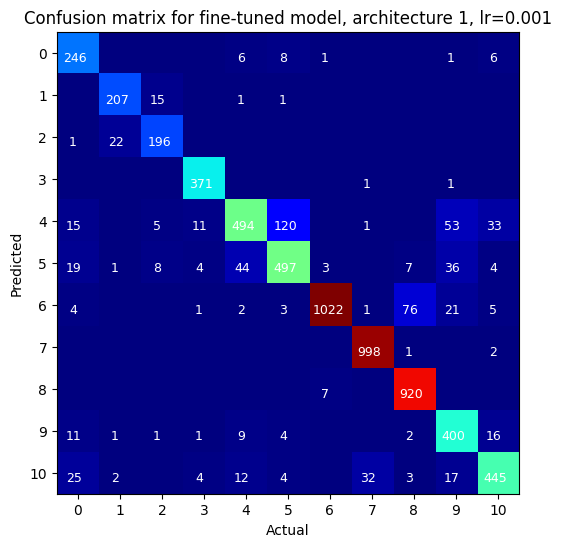

In [ ]:
# Model predictions and confusion matrix
val_predictions_2, val_labels_2 = get_predictions3_8(res_model_2, DataLoader(val_data, batch_size=512, shuffle=True), device)

# Updated call with num_classes
val_error_2, val_conf_mat = calc_error(val_predictions_2, val_labels_2, num_classes=11)
print('Validation error: %.1f%%' % val_error_2)

num_classes = 11

plt.figure(figsize=(6, 6))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(False)
plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.title("Confusion matrix for fine-tuned model, architecture 1, lr=0.001")
plt.imshow(val_conf_mat, cmap=plt.cm.jet, interpolation='nearest');

for i, cas in enumerate(val_conf_mat):
    for j, count in enumerate(cas):
        if count > 0:
            xoff = .07 * len(str(count))
            plt.text(j-xoff, i+.2, int(count), fontsize=9, color='white')

#### Second Architecture

##### Training

##### Lr = 0.005

In [ ]:
# Load pretrained model
res_model_3 = torchvision.models.resnet18(pretrained=True)

# Free weights and modify fully connected layers
for param in res_model_3.parameters():
    param.requires_grad = False

res_model_3.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 11)
)

# Set device
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple M-series chip GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

res_model_3.to(device)
print(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


cuda


In [ ]:
# Train and evaluate the model

optimizer_3 = optim.Adam(res_model_3.parameters(), lr=0.005)

start_time = time.time()
history_3 = train3_8(res_model_3, optimizer_3, train_data, val_data, test_data, num_epochs=10)
end_time = time.time()

print(f"\nTraining Time: {end_time - start_time:.2f} seconds")

# Save model and history
torch.save(res_model_3.state_dict(), 'drive/MyDrive/COMP551_A3/3.8_model_arch_2_lr_0.005.pth')

fobj = open('drive/MyDrive/COMP551_A3/3.8_history_arch_2_lr_0.005.pkl', 'wb')
pickle.dump(history_3, fobj)
fobj.close()

# Final Results
print(f"Final Train Accuracy: {history_3['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history_3['val_acc'][-1]:.2f}%")

Epoch 1/10: 100%|██████████| 68/68 [00:23<00:00,  2.94it/s]


Total samples: 34561, Correct predictions: 29790
Total samples: 6491, Correct predictions: 5618


100%|██████████| 13/13 [00:03<00:00,  3.27it/s]


Epoch [1/10], Training loss: 0.7771, Train Acc: 86.20%, Val Acc: 86.55%


Epoch 2/10: 100%|██████████| 68/68 [00:24<00:00,  2.76it/s]


...

Epoch [9/10], Training loss: 0.1228, Train Acc: 97.46%, Val Acc: 90.16%


Epoch 10/10: 100%|██████████| 68/68 [00:26<00:00,  2.53it/s]


Total samples: 34561, Correct predictions: 33781
Total samples: 6491, Correct predictions: 5823


100%|██████████| 13/13 [00:04<00:00,  2.70it/s]

Epoch [10/10], Training loss: 0.1059, Train Acc: 97.74%, Val Acc: 89.71%
Training complete!

Training Time: 640.09 seconds
Final Train Accuracy: 97.74%
Final Validation Accuracy: 89.71%


###### Plots

In [ ]:
# Load model
res_model_3 = torchvision.models.resnet18(pretrained=False)
res_model_3.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 11)
)
res_model_3.to(device)

# Load the saved state_dict
res_model_3.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.8_model_arch_2_lr_0.005.pth', map_location=torch.device(device)))
res_model_3.eval()

# Load the saved history
fobj = open('drive/MyDrive/COMP551_A3/3.8_history_arch_2_lr_0.005.pkl', 'rb')
history_3 = pickle.load(fobj)
fobj.close()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-33-2ee24170a86c>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recomme

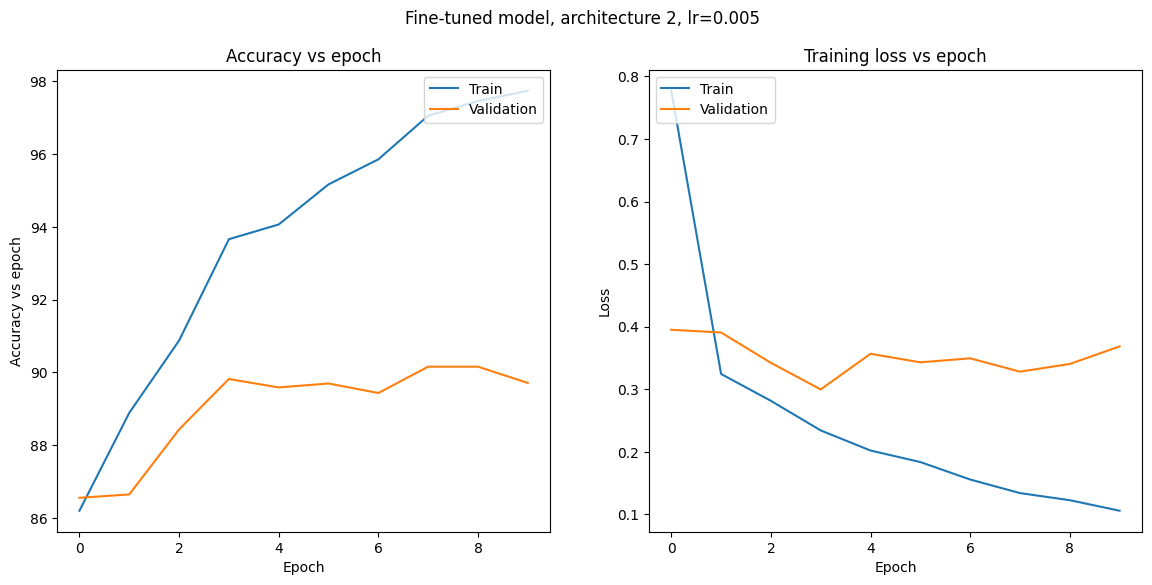

In [ ]:
# Plot training history

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# History for accuracy
ax = plt.subplot(1, 2, 1)
ax.plot(history_3['train_acc'])
ax.plot(history_3['val_acc'])
ax.set_title('Accuracy vs epoch')
ax.set_ylabel('Accuracy vs epoch')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper right')

# History for loss
ax = plt.subplot(1, 2, 2)
ax.plot(history_3['train_loss'])
ax.plot(history_3['val_loss'])
ax.set_title('Training loss vs epoch')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper left')

fig.suptitle("Fine-tuned model, architecture 2, lr=0.005")
plt.show()

100%|██████████| 13/13 [00:04<00:00,  3.19it/s]


(6491,)
Validation error: 10.3%


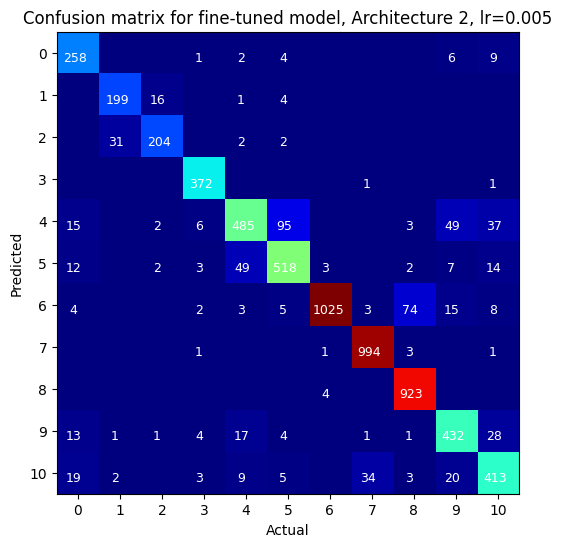

In [ ]:
# Model predictions and confusion matrix
val_predictions_3, val_labels_3 = get_predictions3_8(res_model_3, DataLoader(val_data, batch_size=512, shuffle=True), device)

# Updated call with num_classes
val_error_3, val_conf_mat = calc_error(val_predictions_3, val_labels_3, num_classes=11)
print('Validation error: %.1f%%' % val_error_3)

num_classes = 11

plt.figure(figsize=(6, 6))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(False)
plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.title("Confusion matrix for fine-tuned model, Architecture 2, lr=0.005")
plt.imshow(val_conf_mat, cmap=plt.cm.jet, interpolation='nearest');

for i, cas in enumerate(val_conf_mat):
    for j, count in enumerate(cas):
        if count > 0:
            xoff = .07 * len(str(count))
            plt.text(j-xoff, i+.2, int(count), fontsize=9, color='white')

##### Lr = 0.001

In [ ]:
res_model_4 = torchvision.models.resnet18(pretrained=True)
for param in res_model_4.parameters():
    param.requires_grad = False

res_model_4.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 11)
)

# Set device
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple M-series chip GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

res_model_4.to(device)
print(device)

cuda


In [ ]:
# Train and evaluate the model, LR=0.001

optimizer_4 = optim.Adam(res_model_4.parameters(), lr=0.001)

start_time = time.time()
history_4 = train3_8(res_model_4, optimizer_4, train_data, val_data, test_data, num_epochs=10)
end_time = time.time()

print(f"\nTraining Time: {end_time - start_time:.2f} seconds")

# Save model and history
torch.save(res_model_4.state_dict(), 'drive/MyDrive/COMP551_A3/3.8_model_arch_2_lr_0.001.pth')

fobj = open('drive/MyDrive/COMP551_A3/3.8_history_arch_2_lr_0.001.pkl', 'wb')
pickle.dump(history_4, fobj)
fobj.close()

# Final Results
print(f"Final Train Accuracy: {history_4['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history_4['val_acc'][-1]:.2f}%")

Epoch 1/10: 100%|██████████| 68/68 [00:23<00:00,  2.84it/s]


Total samples: 34561, Correct predictions: 29687
Total samples: 6491, Correct predictions: 5537


100%|██████████| 13/13 [00:06<00:00,  1.97it/s]


Epoch [1/10], Training loss: 0.7726, Train Acc: 85.90%, Val Acc: 85.30%


Epoch 2/10: 100%|██████████| 68/68 [00:32<00:00,  2.06it/s]


...

Epoch [9/10], Training loss: 0.1733, Train Acc: 95.52%, Val Acc: 89.14%


Epoch 10/10: 100%|██████████| 68/68 [00:23<00:00,  2.93it/s]


Total samples: 34561, Correct predictions: 33051
Total samples: 6491, Correct predictions: 5775


100%|██████████| 13/13 [00:04<00:00,  3.21it/s]

Epoch [10/10], Training loss: 0.1626, Train Acc: 95.63%, Val Acc: 88.97%
Training complete!

Training Time: 575.01 seconds
Final Train Accuracy: 95.63%
Final Validation Accuracy: 88.97%


###### Plots

In [ ]:
# Load model
res_model_4 = torchvision.models.resnet18(pretrained=False)
res_model_4.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 11)
)
res_model_4.to(device)

# Load the saved state_dict

res_model_4.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.8_model_arch_2_lr_0.001.pth', map_location=torch.device(device)))
res_model_4.eval()

# Load the saved history
fobj = open('drive/MyDrive/COMP551_A3/3.8_history_arch_2_lr_0.001.pkl', 'rb')
history_4 = pickle.load(fobj)
fobj.close()

<ipython-input-38-b4d6f395fba1>:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res_model_4.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.8_model_arch_2_lr_0.001.

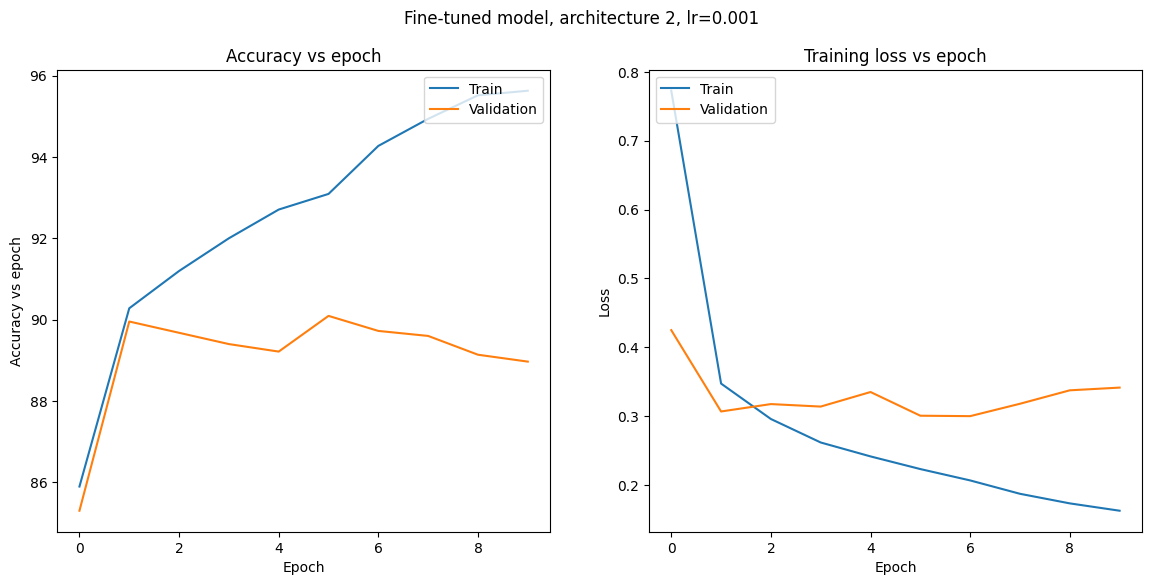

In [ ]:
# Plot training history

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# History for accuracy
ax = plt.subplot(1, 2, 1)
ax.plot(history_4['train_acc'])
ax.plot(history_4['val_acc'])
ax.set_title('Accuracy vs epoch')
ax.set_ylabel('Accuracy vs epoch')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper right')

# History for loss
ax = plt.subplot(1, 2, 2)
ax.plot(history_4['train_loss'])
ax.plot(history_4['val_loss'])
ax.set_title('Training loss vs epoch')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(['Train', 'Validation'], loc='upper left')

fig.suptitle("Fine-tuned model, architecture 2, lr=0.001")
plt.show()

100%|██████████| 13/13 [00:04<00:00,  3.02it/s]


(6491,)
Validation error: 11.0%


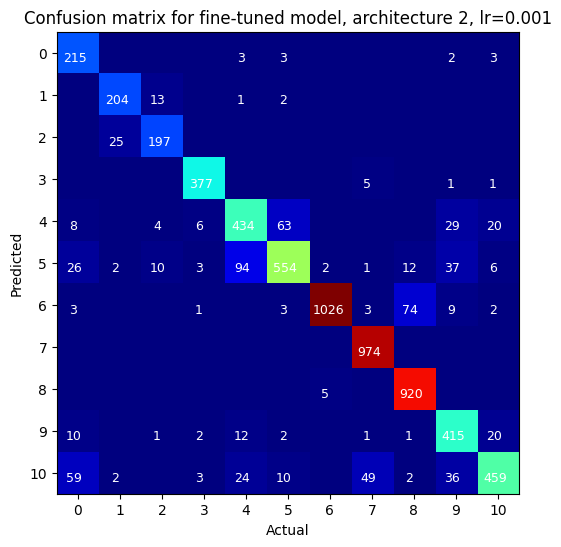

In [ ]:
# Model predictions and confusion matrix
val_predictions_4, val_labels_4 = get_predictions3_8(res_model_4, DataLoader(val_data, batch_size=512, shuffle=True), device)

# Updated call with num_classes
val_error_4, val_conf_mat = calc_error(val_predictions_4, val_labels_4, num_classes=11)
print('Validation error: %.1f%%' % val_error_4)

num_classes = 11

plt.figure(figsize=(6, 6))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(False)
plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.title("Confusion matrix for fine-tuned model, architecture 2, lr=0.001")
plt.imshow(val_conf_mat, cmap=plt.cm.jet, interpolation='nearest');

for i, cas in enumerate(val_conf_mat):
    for j, count in enumerate(cas):
        if count > 0:
            xoff = .07 * len(str(count))
            plt.text(j-xoff, i+.2, int(count), fontsize=9, color='white')

#### Choosing the best configuration

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple M-series chip GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

cpu


In [ ]:
# Load model
res_model = torchvision.models.resnet18(pretrained=False)
res_model.fc = nn.Linear(512, 11)
res_model.to(device)

# Load the saved state_dict
res_model.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.8_model_lr_0.005.pth', map_location=torch.device(device)))
res_model.eval()

# Load the saved history
fobj = open('drive/MyDrive/COMP551_A3/3.8_history_lr_0.005.pkl', 'rb')
history = pickle.load(fobj)
fobj.close()

# Load model
res_model_2 = torchvision.models.resnet18(pretrained=False)
res_model_2.fc = nn.Linear(512, 11)
res_model_2.to(device)

# Load the saved state_dict

res_model_2.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.8_model_lr_0.001.pth', map_location=torch.device(device)))
res_model_2.eval()

# Load the saved history
fobj = open('drive/MyDrive/COMP551_A3/3.8_history_lr_0.001.pkl', 'rb')
history_2 = pickle.load(fobj)
fobj.close()

# Load model
res_model_3 = torchvision.models.resnet18(pretrained=False)
res_model_3.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 11)
)
res_model_3.to(device)

# Load the saved state_dict
res_model_3.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.8_model_arch_2_lr_0.005.pth', map_location=torch.device(device)))
res_model_3.eval()

# Load the saved history
fobj = open('drive/MyDrive/COMP551_A3/3.8_history_arch_2_lr_0.005.pkl', 'rb')
history_3 = pickle.load(fobj)
fobj.close()

# Load model
res_model_4 = torchvision.models.resnet18(pretrained=False)
res_model_4.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 11)
)
res_model_4.to(device)

# Load the saved state_dict

res_model_4.load_state_dict(torch.load('drive/MyDrive/COMP551_A3/3.8_model_arch_2_lr_0.001.pth', map_location=torch.device(device)))
res_model_4.eval()

# Load the saved history
fobj = open('drive/MyDrive/COMP551_A3/3.8_history_arch_2_lr_0.001.pkl', 'rb')
history_4 = pickle.load(fobj)
fobj.close()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-55-9be873be6387>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions

In [ ]:
def get_best_index_from_history(history_list):
    final_val_loss = []
    for history in history_list:
        final_val_loss.append(history['val_loss'][-1])

    return np.argmin(np.array(final_val_loss))


all_res_histories = [history, history_2, history_3, history_4]
all_res_models = [res_model, res_model_2, res_model_3, res_model_4]

best_index_3_8 = get_best_index_from_history(all_res_histories)
print(best_index_3_8)

1


So the configuration that minimizes the final validation loss is the first architecture (flattened layer to num_classes), using lr=0.001.

##### Plots comparing all fine-tuned models

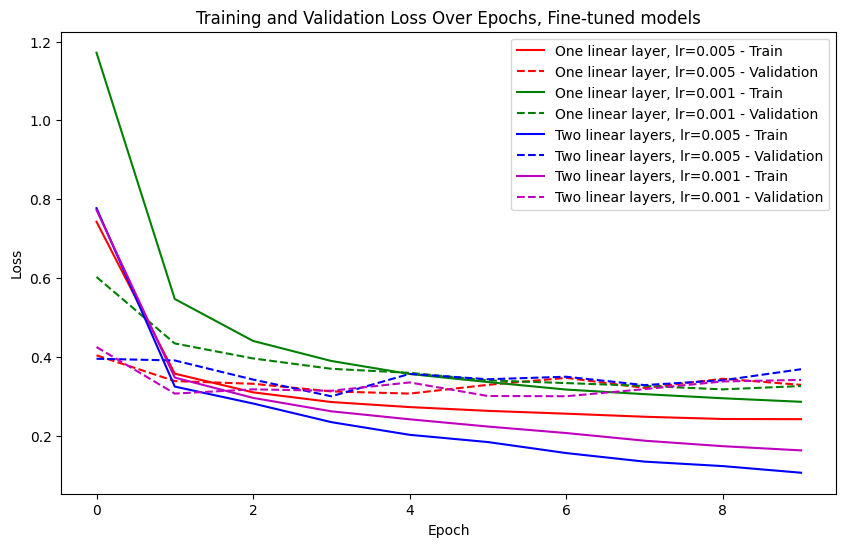

In [ ]:
fine_tuned_model_histories = [history, history_2, history_3, history_4]

i = 0
color = ['r', 'g', 'b', 'm']
color_2 = ['r--', 'g--', 'b--', 'm--']
labels = ['One linear layer, lr=0.005', 'One linear layer, lr=0.001', 'Two linear layers, lr=0.005', 'Two linear layers, lr=0.001']
plt.figure(figsize=(10, 6))

for model_history in fine_tuned_model_histories:
    plt.plot(np.arange(len(model_history['train_loss'])), model_history['train_loss'], color[i], label=f'{labels[i]} - Train')
    plt.plot(np.arange(len(model_history['val_loss'])), model_history['val_loss'], color_2[i], label=f'{labels[i]} - Validation')
    i += 1

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs, Fine-tuned models')
plt.show()

##### Train and validation loss vs epoch (best)

Text(0.5, 1.0, 'Training and Validation Loss Over Epochs')

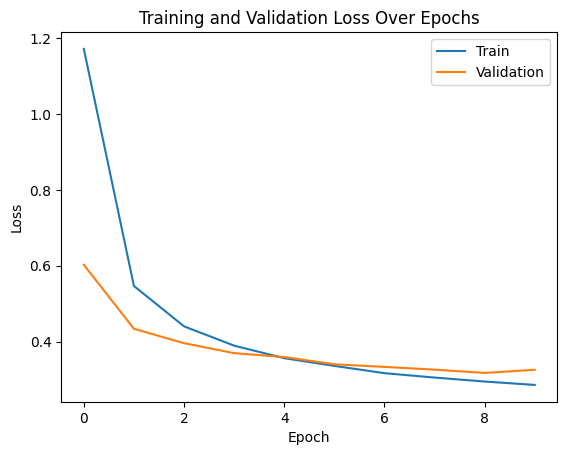

In [ ]:
best_model = all_res_models[best_index_3_8]
best_model_history = all_res_histories[best_index_3_8]

plt.plot(np.arange(len(best_model_history['train_loss'])), best_model_history['train_loss'], label='Train')
plt.plot(np.arange(len(best_model_history['val_loss'])), best_model_history['val_loss'], label='Validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')

##### Test accuracy (best)

In [ ]:
test_loader = DataLoader(test_data, batch_size=512, shuffle=True)
test_acc_3_8 = compute_accuracy3_8(best_model, test_loader, device)
print(f"Test Accuracy: {test_acc_3_8:.2f}%")

Total samples: 17778, Correct predictions: 14900
Test Accuracy: 83.81%


In [ ]:
# Retrieve results from 3.7
fobj = open(f'drive/MyDrive/COMP551_A3/3.7_results.pkl', 'rb')
results = pickle.load(fobj)
fobj.close()

# Save results from 3.8
results_3_8 = (best_model_history['train_acc'][-1]/100,
                                      best_model_history['val_acc'][-1]/100,
                                      test_acc_3_8/100)

results["Fine-tuned ResNet18"] = results_3_8

fobj = open(f'drive/MyDrive/COMP551_A3/3.8_results.pkl', 'wb')
pickle.dump(results, fobj)
fobj.close()

### Comparing all models

#### Accuracy

In [ ]:
fobj = open(f'drive/MyDrive/COMP551_A3/3.8_results.pkl', 'rb')
results = pickle.load(fobj)
fobj.close()

In [ ]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=["Train Accuracy", "Validation Accuracy", "Test Accuracy"])
print(results_df)

                                    Train Accuracy  Validation Accuracy  \
No Hidden Layers                          0.769364             0.828378   
Single Hidden Layer                       0.902810             0.892158   
Two Hidden Layers                         0.931802             0.901402   
Two Hidden Layers (Tanh)                  0.994271             0.902018   
Two Hidden Layers (Leaky-ReLU)            0.931194             0.902172   
Two Hidden Layers (ReLU + L1)             0.997685             0.915729   
Two Hidden Layers (ReLU + L2)             0.963253             0.935911   
Two Hidden Layers (Unnormalized)          0.800874             0.894007   
Two Hidden Layers (128x128 pixels)        0.995891             0.925589   
CNN, filter=8, kernel=3                   0.999884             0.954090   
CNN 128x128, filter=8, kernel=3           0.999421             0.937298   
Fine-tuned ResNet18                       0.913689             0.892929   

                        

We have already established at the end that the best MLP model is the one with two hidden layers with ReLU activation and L2 regularization.

In [ ]:
import copy

results_filtered = copy.deepcopy(results)
del results_filtered['No Hidden Layers']
del results_filtered['Single Hidden Layer']
del results_filtered['Two Hidden Layers']
del results_filtered['Two Hidden Layers (Tanh)']
del results_filtered['Two Hidden Layers (Leaky-ReLU)']
del results_filtered['Two Hidden Layers (ReLU + L1)']
del results_filtered['Two Hidden Layers (Unnormalized)']
del results_filtered['Two Hidden Layers (128x128 pixels)']

print(results_filtered)
print(len(results_filtered))

{'Two Hidden Layers (ReLU + L2)': (0.9632533780851249, 0.9359112617470343, 0.7456406794915064), 'CNN, filter=8, kernel=3': (0.9998842600000001, 0.9540902800000001, 0.844639), 'CNN 128x128, filter=8, kernel=3': (0.99942131, 0.9372978000000001, 0.81719), 'Fine-tuned ResNet18': (0.91368884, 0.89292867, 0.838115)}
4


In [ ]:
results_df = pd.DataFrame.from_dict(results_filtered, orient='index', columns=["Train Accuracy", "Validation Accuracy", "Test Accuracy"])
print(results_df)

                                 Train Accuracy  Validation Accuracy  \
Two Hidden Layers (ReLU + L2)          0.963253             0.935911   
CNN, filter=8, kernel=3                0.999884             0.954090   
CNN 128x128, filter=8, kernel=3        0.999421             0.937298   
Fine-tuned ResNet18                    0.913689             0.892929   

                                 Test Accuracy  
Two Hidden Layers (ReLU + L2)         0.745641  
CNN, filter=8, kernel=3               0.844639  
CNN 128x128, filter=8, kernel=3       0.817190  
Fine-tuned ResNet18                   0.838115  


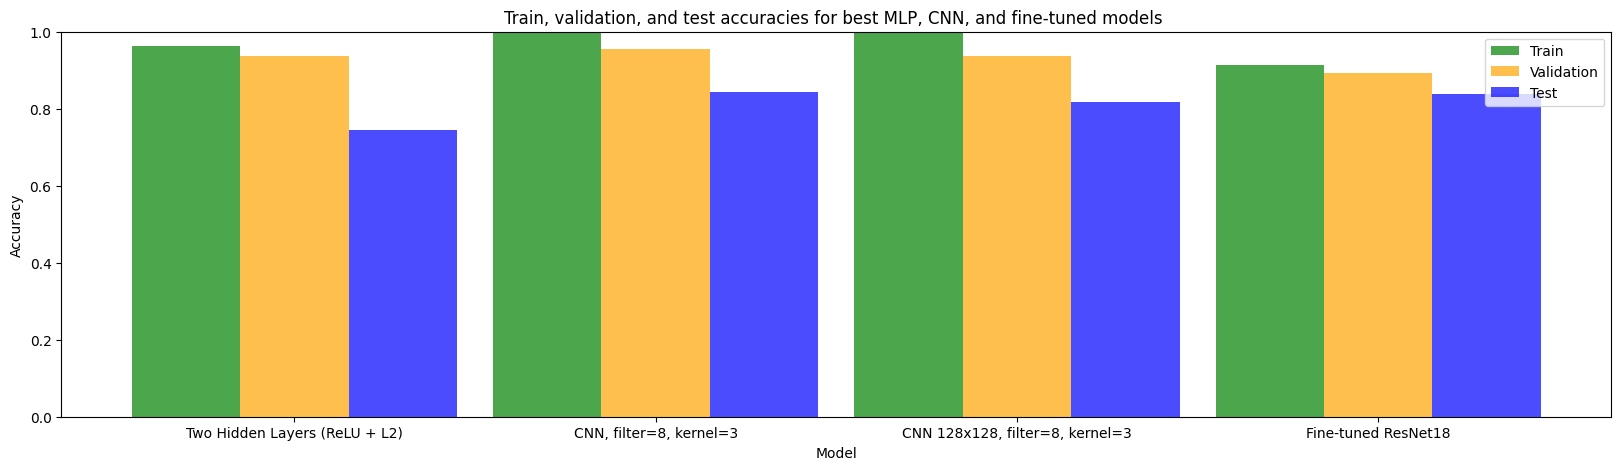

In [ ]:
# Plot accuracies

train_accuracies = {model: acc[0] for model, acc in results_filtered.items()}
val_accuracies = {model: acc[1] for model, acc in results_filtered.items()}
test_accuracies = {model: acc[2] for model, acc in results_filtered.items()}

plt.figure(figsize=(20,5))
ind = np.arange(4)
width = 0.3

# Plotting
plt.bar(ind, train_accuracies.values(), width, color='green', alpha=0.7, label='Train')
plt.bar(ind + width, val_accuracies.values(), width, color='orange', alpha=0.7, label='Validation')
plt.bar(ind + 2*width, test_accuracies.values(), width, color='blue', alpha=0.7, label='Test')

plt.title("Train, validation, and test accuracies for best MLP, CNN, and fine-tuned models ")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.ylim(0, 1)

plt.xticks(ind + width, train_accuracies.keys())
plt.show()

#### Loss and convergence

Text(0.5, 1.0, 'Training and Validation Loss Over Epochs')

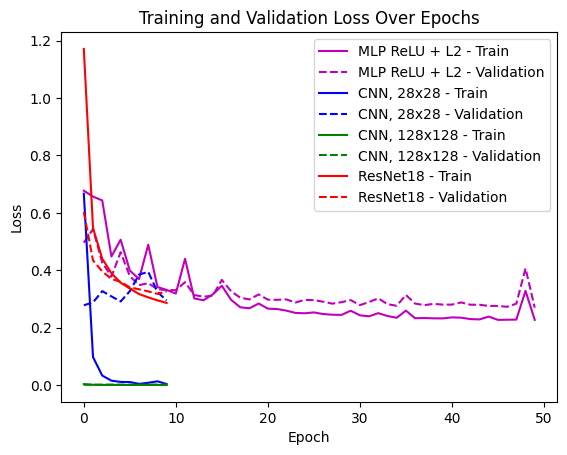

In [ ]:
fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_models_v3.pkl', 'rb')
l2_all_models_v3 = pickle.load(fobj)
fobj.close()

best_mlp_model = l2_all_models_v3[(0.01, 1)]

plt.plot(best_mlp_model.train_loss_history, 'm', label='MLP ReLU + L2 - Train')
plt.plot(best_mlp_model.val_loss_history, 'm--', label='MLP ReLU + L2 - Validation')
plt.plot(np.arange(len(best_model_history_3_6['train_loss'])), best_model_history_3_6['train_loss'],'b', label='CNN, 28x28 - Train')
plt.plot(np.arange(len(best_model_history_3_6['val_loss'])), best_model_history_3_6['val_loss'], 'b--', label='CNN, 28x28 - Validation')
plt.plot(np.arange(len(best_model_history_3_7['train_loss'])), best_model_history_3_7['train_loss'], 'g', label='CNN, 128x128 - Train')
plt.plot(np.arange(len(best_model_history_3_7['val_loss'])), best_model_history_3_7['val_loss'], 'g--', label='CNN, 128x128 - Validation')
plt.plot(np.arange(len(best_model_history['train_loss'])), best_model_history['train_loss'], 'r', label='ResNet18 - Train')
plt.plot(np.arange(len(best_model_history['val_loss'])), best_model_history['val_loss'], 'r--', label='ResNet18 - Validation')

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')

Text(0.5, 1.0, 'Training and Validation Loss Over Epochs')

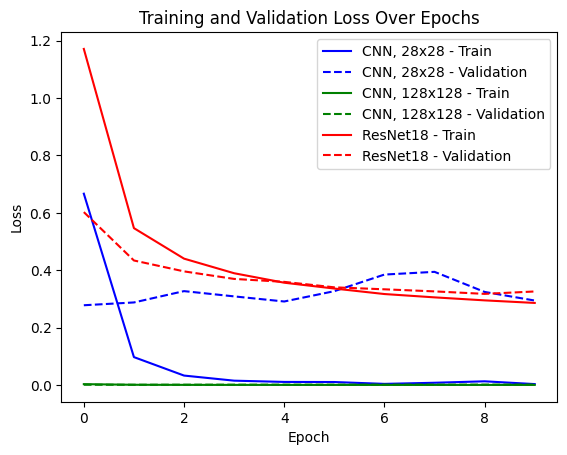

In [ ]:
# Same plot, without MLP

plt.plot(np.arange(len(best_model_history_3_6['train_loss'])), best_model_history_3_6['train_loss'],'b', label='CNN, 28x28 - Train')
plt.plot(np.arange(len(best_model_history_3_6['val_loss'])), best_model_history_3_6['val_loss'], 'b--', label='CNN, 28x28 - Validation')
plt.plot(np.arange(len(best_model_history_3_7['train_loss'])), best_model_history_3_7['train_loss'], 'g', label='CNN, 128x128 - Train')
plt.plot(np.arange(len(best_model_history_3_7['val_loss'])), best_model_history_3_7['val_loss'], 'g--', label='CNN, 128x128 - Validation')
plt.plot(np.arange(len(best_model_history['train_loss'])), best_model_history['train_loss'], 'r', label='ResNet18 - Train')
plt.plot(np.arange(len(best_model_history['val_loss'])), best_model_history['val_loss'], 'r--', label='ResNet18 - Validation')

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')